# Pakistan Inflation & Interest Rate Business Impact Analysis
Subtitle: Economic Trends, Stress Analysis & Business Risk Assessment

### Project Purpose
Analyze Pakistan’s economic indicators from 2000–2025 to understand how inflation, interest rates, exchange rates, economic growth, investment, trade and public debt influence the business environment and business risk.

#### By the end of this project, we aim to identify:
 - Inflation trends and major inflationary periods in Pakistan.
 - Interest-rate and monetary policy patterns, including tightening and easing periods.
 - GDP growth and business-cycle movements - expansion, slowdown, contraction and recovery.
 - PKR depreciation and its relationship with inflation and trade.
 - Impact of interest rates and inflation on investment and business activity.
 - Relationship between economic growth and unemployment.
 - Changes in FDI, exports, imports and public debt across economic periods.
 - Major economic stress periods based on multiple indicators.
 - Business impact of macroeconomic conditions on costs, demand, financing, investment and profitability.
 - Key economic risks and indicators businesses should monitor for forecasting and decision-making.

Main target:
 - Understand how changes in Pakistan’s economic environment translate into business opportunities, risks, costs and decision-making.

#### PART 1 — Dataset & Business Understanding

In [8]:
# Pakistan Economic Analysis
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

In [10]:
# Load the dataset
df = pd.read_csv("Downloads/pakistan_economic_indicators_2000_2025.csv")
df.head()

,year,gdp_usd_bn,gdp_growth_pct,gdp_per_capita_usd,inflation_cpi_pct,unemployment_pct,remittances_usd_bn,exports_usd_bn,imports_usd_bn,trade_balance_usd_bn,forex_reserves_usd_bn,policy_rate_pct,pkr_per_usd,public_debt_gdp_pct,current_account_usd_bn,fdi_inflows_usd_bn,population_mn,literacy_rate_pct,agriculture_gdp_pct,services_gdp_pct,industry_gdp_pct,tax_revenue_gdp_pct,mobile_per_100,imf_program_active,key_events,remittances_gdp_pct,exports_gdp_pct,imports_gdp_pct,fdi_gdp_pct,gdp_growth_category,inflation_category,decade
0,2000,99.90,3.90,624,4.40,7.80,1.08,9.20,10.30,-1.10,1.70,13.00,51.80,82.00,-0.20,0.31,142.30,43.90,26.00,47.20,26.80,9.30,0.30,0,Post-sanctions recovery,1.08,9.21,10.31,0.31,Moderate Growth,Low,2000s
1,2001,101.40,2.00,614,3.10,7.80,1.46,9.80,10.30,-0.50,3.00,12.00,61.40,79.00,0.30,0.38,145.50,45.00,25.10,47.80,27.10,9.70,0.60,0,9/11 impact + debt relief,1.44,9.66,10.16,0.37,Low Growth,Low,2000s
2,2002,107.60,3.10,628,3.50,8.30,2.39,10.00,10.90,-0.90,4.80,7.50,59.70,75.00,3.90,0.82,148.70,46.00,24.30,48.00,27.70,10.10,1.80,0,Economic reform start,2.22,9.29,10.13,0.76,Moderate Growth,Low,2000s
3,2003,116.30,4.70,657,3.10,8.30,3.96,11.70,12.20,-0.50,9.50,7.50,57.80,68.00,4.10,0.53,151.90,47.00,23.50,49.10,27.40,10.50,3.30,0,Growth acceleration,3.40,10.06,10.49,0.46,Moderate Growth,Low,2000s
4,2004,126.70,7.40,697,7.40,7.70,3.87,14.00,15.50,-1.50,10.60,7.50,57.60,65.00,1.50,1.12,155.10,48.70,22.50,50.50,27.00,10.50,7.70,0,High growth period,3.05,11.05,12.23,0.88,High Growth,Moderate,2000s


In [14]:
# Dataset Overview
# How many rows and columns are there? What period does the dataset cover? What does each row represent?
# Which variables are numerical and categorical/text?
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nPeriod covered:")
print(df["year"].min(), "to", df["year"].max())

print("\nEach row represents:")
print("One year of Pakistan's economic indicators.")

print("\nNumerical columns:")
print(df.select_dtypes(include="number").columns.tolist())

print("\nCategorical/Text columns:")
print(df.select_dtypes(include="object").columns.tolist())

Number of rows: 26
Number of columns: 32

Period covered:
2000 to 2025

Each row represents:
One year of Pakistan's economic indicators.

Numerical columns:
['year', 'gdp_usd_bn', 'gdp_growth_pct', 'gdp_per_capita_usd', 'inflation_cpi_pct', 'unemployment_pct', 'remittances_usd_bn', 'exports_usd_bn', 'imports_usd_bn', 'trade_balance_usd_bn', 'forex_reserves_usd_bn', 'policy_rate_pct', 'pkr_per_usd', 'public_debt_gdp_pct', 'current_account_usd_bn', 'fdi_inflows_usd_bn', 'population_mn', 'literacy_rate_pct', 'agriculture_gdp_pct', 'services_gdp_pct', 'industry_gdp_pct', 'tax_revenue_gdp_pct', 'mobile_per_100', 'imf_program_active', 'remittances_gdp_pct', 'exports_gdp_pct', 'imports_gdp_pct', 'fdi_gdp_pct']

Categorical/Text columns:
['key_events', 'gdp_growth_category', 'inflation_category', 'decade']


In [16]:
# Data Quality
# Check for: Missing values, Duplicate rows, Incorrect data types, Impossible/abnormal values, Percentage variables stored incorrectly
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistical summary:")
display(df.describe().T)

Missing values:
year                      0
gdp_usd_bn                0
gdp_growth_pct            0
gdp_per_capita_usd        0
inflation_cpi_pct         0
unemployment_pct          0
remittances_usd_bn        0
exports_usd_bn            0
imports_usd_bn            0
trade_balance_usd_bn      0
forex_reserves_usd_bn     0
policy_rate_pct           0
pkr_per_usd               0
public_debt_gdp_pct       0
current_account_usd_bn    0
fdi_inflows_usd_bn        0
population_mn             0
literacy_rate_pct         0
agriculture_gdp_pct       0
services_gdp_pct          0
industry_gdp_pct          0
tax_revenue_gdp_pct       0
mobile_per_100            0
imf_program_active        0
key_events                0
remittances_gdp_pct       0
exports_gdp_pct           0
imports_gdp_pct           0
fdi_gdp_pct               0
gdp_growth_category       0
inflation_category        0
decade                    0
dtype: int64

Duplicate rows:
0

Data types:
year                        int64
gdp_usd_b

,count,mean,std,min,25%,50%,75%,max
year,26.00,2012.50,7.65,2000.00,2006.25,2012.50,2018.75,2025.00
gdp_usd_bn,26.00,233.08,92.28,99.90,156.30,243.35,299.38,390.00
gdp_growth_pct,26.00,4.11,2.20,-0.50,2.70,4.10,5.65,9.00
gdp_per_capita_usd,26.00,1012.15,258.43,614.00,807.00,1040.50,1226.00,1393.00
inflation_cpi_pct,26.00,9.36,6.43,2.90,4.65,7.75,11.20,29.20
unemployment_pct,26.00,6.26,1.06,4.50,5.65,6.00,6.47,8.30
remittances_usd_bn,26.00,14.87,10.78,1.08,5.38,13.55,21.93,38.00
exports_usd_bn,26.00,21.45,6.91,9.20,17.77,22.00,24.80,34.00
imports_usd_bn,26.00,39.85,18.57,10.30,29.08,44.10,48.47,80.00
trade_balance_usd_bn,26.00,-18.40,12.20,-47.60,-22.77,-20.25,-11.30,-0.50


In [18]:
# Check percentage-based variables
percentage_columns = [
    "gdp_growth_pct",
    "inflation_cpi_pct",
    "unemployment_pct",
    "policy_rate_pct",
    "public_debt_gdp_pct",
    "literacy_rate_pct",
    "agriculture_gdp_pct",
    "services_gdp_pct",
    "industry_gdp_pct",
    "tax_revenue_gdp_pct",
    "remittances_gdp_pct",
    "exports_gdp_pct",
    "imports_gdp_pct",
    "fdi_gdp_pct"]
df[percentage_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
gdp_growth_pct,26.00,4.11,2.20,-0.50,2.70,4.10,5.65,9.00
inflation_cpi_pct,26.00,9.36,6.43,2.90,4.65,7.75,11.20,29.20
unemployment_pct,26.00,6.26,1.06,4.50,5.65,6.00,6.47,8.30
policy_rate_pct,26.00,10.63,3.77,5.75,7.50,10.00,12.88,22.00
public_debt_gdp_pct,26.00,67.65,8.95,55.00,60.50,66.00,73.75,87.00
literacy_rate_pct,26.00,56.20,6.04,43.90,52.40,58.05,60.10,64.00
agriculture_gdp_pct,26.00,22.44,1.30,20.90,21.50,22.40,22.90,26.00
services_gdp_pct,26.00,51.83,1.91,47.20,51.17,52.30,53.08,54.10
industry_gdp_pct,26.00,25.73,0.94,24.30,25.02,25.65,26.35,27.70
tax_revenue_gdp_pct,26.00,11.27,1.42,9.10,10.22,10.85,12.35,14.50


In [20]:
# Check for impossible negative values in variables where negatives would generally not make sense
positive_columns = [
    "gdp_usd_bn",
    "gdp_per_capita_usd",
    "unemployment_pct",
    "population_mn",
    "literacy_rate_pct",
    "mobile_per_100"]
for col in positive_columns:
    print(f"{col}: {(df[col] < 0).sum()} negative values")

gdp_usd_bn: 0 negative values
gdp_per_capita_usd: 0 negative values
unemployment_pct: 0 negative values
population_mn: 0 negative values
literacy_rate_pct: 0 negative values
mobile_per_100: 0 negative values


In [22]:
# Variable Selection
# Identify variables most relevant to: Inflation → Interest Rates → Economic Growth → Business Environment
selected_variables = [
    "year",
    "inflation_cpi_pct",
    "policy_rate_pct",
    "gdp_growth_pct",
    "unemployment_pct",
    "pkr_per_usd",
    "fdi_inflows_usd_bn",
    "exports_usd_bn",
    "imports_usd_bn",
    "public_debt_gdp_pct",
    "current_account_usd_bn"]
selected_df = df[selected_variables]
selected_df.head()

,year,inflation_cpi_pct,policy_rate_pct,gdp_growth_pct,unemployment_pct,pkr_per_usd,fdi_inflows_usd_bn,exports_usd_bn,imports_usd_bn,public_debt_gdp_pct,current_account_usd_bn
0,2000,4.40,13.00,3.90,7.80,51.80,0.31,9.20,10.30,82.00,-0.20
1,2001,3.10,12.00,2.00,7.80,61.40,0.38,9.80,10.30,79.00,0.30
2,2002,3.50,7.50,3.10,8.30,59.70,0.82,10.00,10.90,75.00,3.90
3,2003,3.10,7.50,4.70,8.30,57.80,0.53,11.70,12.20,68.00,4.10
4,2004,7.40,7.50,7.40,7.70,57.60,1.12,14.00,15.50,65.00,1.50


#### Part 1 Final Finding
The dataset is complete, correctly structured and suitable for analyzing Pakistan's macroeconomic environment from 2000 - 2025. The selected indicators provide a focused framework for examining how inflation, monetary policy, growth, currency movements, investment, trade and government conditions interact with the business environment.

#### Part 2 — Economic Environment Analysis

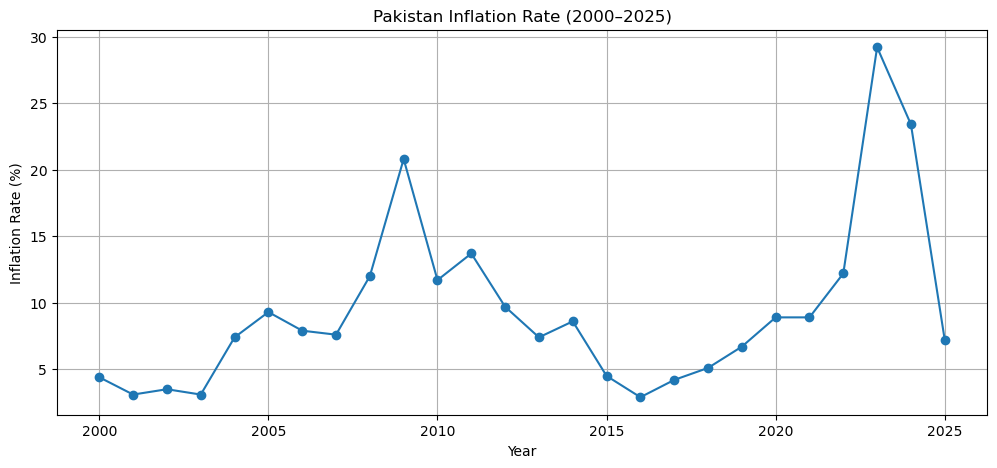

In [28]:
# Inflation Trend
# How has Pakistan's inflation rate changed from 2000–2025?
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["inflation_cpi_pct"],
    marker="o")
plt.title("Pakistan Inflation Rate (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.grid(True)
plt.show()

In [30]:
# Highest inflation year
highest_inflation = df.loc[
    df["inflation_cpi_pct"].idxmax()]
# Lowest inflation year
lowest_inflation = df.loc[
    df["inflation_cpi_pct"].idxmin()]
print("Highest Inflation:")
print(highest_inflation[["year", "inflation_cpi_pct"]])

print("\nLowest Inflation:")
print(lowest_inflation[["year", "inflation_cpi_pct"]])

Highest Inflation:
year                 2023
inflation_cpi_pct   29.20
Name: 23, dtype: object

Lowest Inflation:
year                 2016
inflation_cpi_pct    2.90
Name: 16, dtype: object


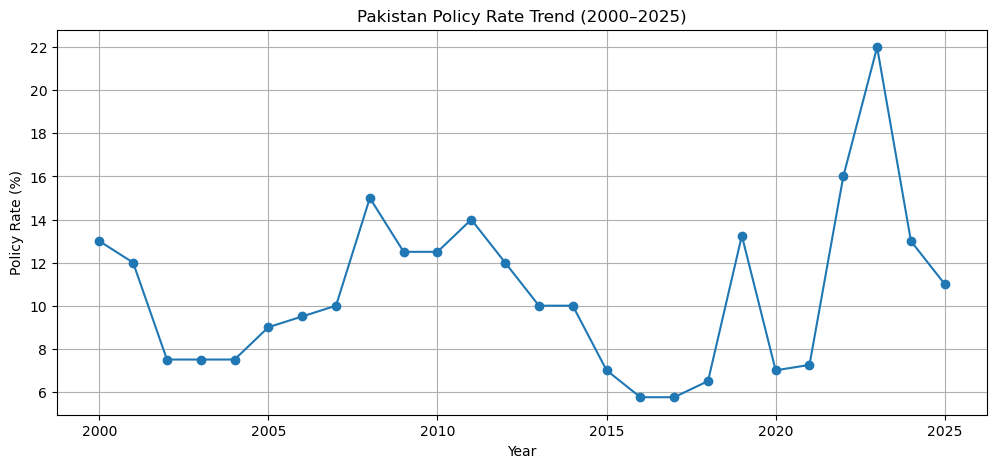

In [32]:
# Policy Rate Trend
# How has Pakistan's policy rate changed from 2000–2025?
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["policy_rate_pct"],
    marker="o")
plt.title("Pakistan Policy Rate Trend (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Policy Rate (%)")
plt.grid(True)
plt.show()

In [34]:
# Highest policy rate
highest_policy_rate = df.loc[
    df["policy_rate_pct"].idxmax()]
# Lowest policy rate
lowest_policy_rate = df.loc[
    df["policy_rate_pct"].idxmin()]
print("Highest Policy Rate:")
print(highest_policy_rate[["year", "policy_rate_pct"]])

print("\nLowest Policy Rate:")
print(lowest_policy_rate[["year", "policy_rate_pct"]])

Highest Policy Rate:
year               2023
policy_rate_pct   22.00
Name: 23, dtype: object

Lowest Policy Rate:
year               2016
policy_rate_pct    5.75
Name: 16, dtype: object


In [36]:
# Calculate year-over-year change in policy rate
df["policy_rate_change"] = df["policy_rate_pct"].diff()
df[["year", "policy_rate_pct", "policy_rate_change"]]

,year,policy_rate_pct,policy_rate_change
0,2000,13.00,NaN
1,2001,12.00,-1.00
2,2002,7.50,-4.50
3,2003,7.50,0.00
4,2004,7.50,0.00
5,2005,9.00,1.50
6,2006,9.50,0.50
7,2007,10.00,0.50
8,2008,15.00,5.00
9,2009,12.50,-2.50


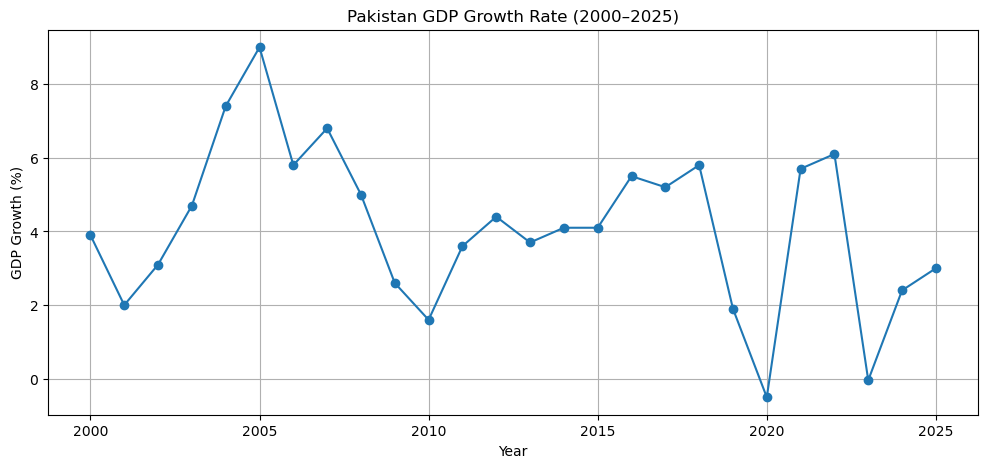

In [38]:
# GDP Growth
# How has GDP growth changed from 2000–2025?
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["gdp_growth_pct"],
    marker="o")
plt.title("Pakistan GDP Growth Rate (2000–2025)")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(True)
plt.show()

In [40]:
# Highest GDP growth
highest_growth = df.loc[
    df["gdp_growth_pct"].idxmax()]
# Lowest GDP growth
lowest_growth = df.loc[
    df["gdp_growth_pct"].idxmin()]
print("Highest GDP Growth:")
print(highest_growth[["year", "gdp_growth_pct"]])

print("\nLowest GDP Growth:")
print(lowest_growth[["year", "gdp_growth_pct"]])

Highest GDP Growth:
year              2005
gdp_growth_pct    9.00
Name: 5, dtype: object

Lowest GDP Growth:
year              2020
gdp_growth_pct   -0.50
Name: 20, dtype: object


In [42]:
# Business Cycle
# Identify possible Expansion → Peak → Contraction → Trough → Recovery periods using GDP growth, inflation and unemployment.
business_cycle_df = df[
    [
        "year",
        "gdp_growth_pct",
        "inflation_cpi_pct",
        "unemployment_pct",
        "policy_rate_pct"]]
business_cycle_df

,year,gdp_growth_pct,inflation_cpi_pct,unemployment_pct,policy_rate_pct
0,2000,3.90,4.40,7.80,13.00
1,2001,2.00,3.10,7.80,12.00
2,2002,3.10,3.50,8.30,7.50
3,2003,4.70,3.10,8.30,7.50
4,2004,7.40,7.40,7.70,7.50
5,2005,9.00,9.30,7.70,9.00
6,2006,5.80,7.90,6.20,9.50
7,2007,6.80,7.60,5.20,10.00
8,2008,5.00,12.00,5.20,15.00
9,2009,2.60,20.80,5.50,12.50


In [44]:
# Calculate annual change in GDP growth
business_cycle_df["gdp_growth_change"] = (
    business_cycle_df["gdp_growth_pct"].diff())
business_cycle_df

,year,gdp_growth_pct,inflation_cpi_pct,unemployment_pct,policy_rate_pct,gdp_growth_change
0,2000,3.90,4.40,7.80,13.00,NaN
1,2001,2.00,3.10,7.80,12.00,-1.90
2,2002,3.10,3.50,8.30,7.50,1.10
3,2003,4.70,3.10,8.30,7.50,1.60
4,2004,7.40,7.40,7.70,7.50,2.70
5,2005,9.00,9.30,7.70,9.00,1.60
6,2006,5.80,7.90,6.20,9.50,-3.20
7,2007,6.80,7.60,5.20,10.00,1.00
8,2008,5.00,12.00,5.20,15.00,-1.80
9,2009,2.60,20.80,5.50,12.50,-2.40


#### Part 2 — Conclusion
 - Inflation was highly volatile, ranging from 2.9% in 2016 to 29.2% in 2023.
 - Policy rates moved sharply in response to changing economic conditions, reaching a high of 22% in 2023.
 - GDP growth was cyclical, with the highest growth of 9% in 2005 and lowest of -0.5% in 2020.
 - 2023 was the most difficult period, combining near-zero growth, very high inflation and the highest policy rate.
 - 2024–2025 showed recovery, with GDP growth improving while inflation and policy rates declined.

Overall Finding
 - Pakistan's business environment was strongly influenced by fluctuations in inflation, interest rates, and economic growth, with 2023 standing out as the major stress period and 2025 showing signs of recovery.

### Part 3 — Inflation & Monetary Policy

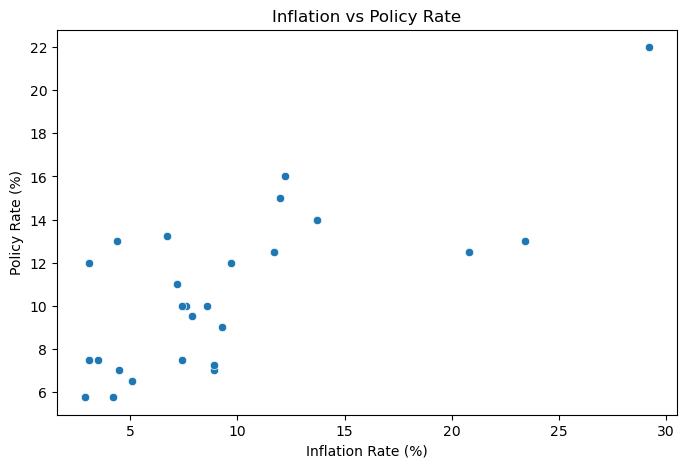

In [48]:
# Inflation vs Policy Rate
# Is there a relationship between inflation and the policy rate?
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="inflation_cpi_pct",
    y="policy_rate_pct")
plt.title("Inflation vs Policy Rate")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("Policy Rate (%)")
plt.show()

In [50]:
# Calculate correlation between inflation and policy rate
inflation_policy_corr = df[
    ["inflation_cpi_pct", "policy_rate_pct"]
].corr()
inflation_policy_corr

,inflation_cpi_pct,policy_rate_pct
inflation_cpi_pct,1.00,0.73
policy_rate_pct,0.73,1.00


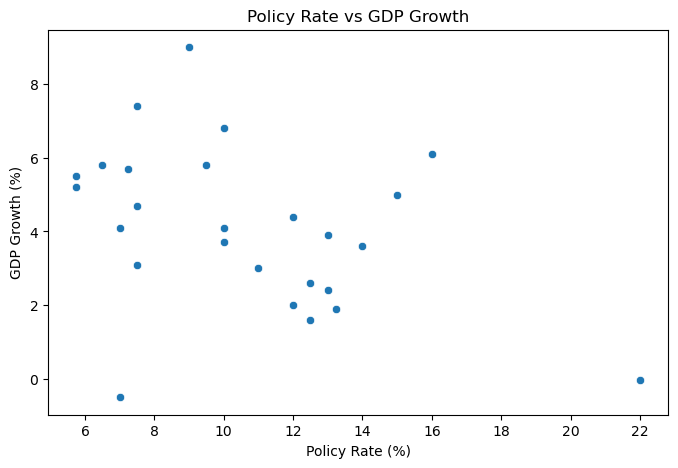

In [52]:
# Interest Rates vs GDP Growth
# Did higher interest rates coincide with lower GDP growth?
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="policy_rate_pct",
    y="gdp_growth_pct")
plt.title("Policy Rate vs GDP Growth")
plt.xlabel("Policy Rate (%)")
plt.ylabel("GDP Growth (%)")
plt.show()

In [54]:
# Calculate correlation between policy rate and GDP growth
policy_growth_corr = df[
    ["policy_rate_pct", "gdp_growth_pct"]
].corr()
policy_growth_corr

,policy_rate_pct,gdp_growth_pct
policy_rate_pct,1.00,-0.40
gdp_growth_pct,-0.40,1.00


Interpretation: A correlation of -0.40 indicates a moderate negative relationship, meaning higher policy rates generally coincided with lower GDP growth in the dataset.

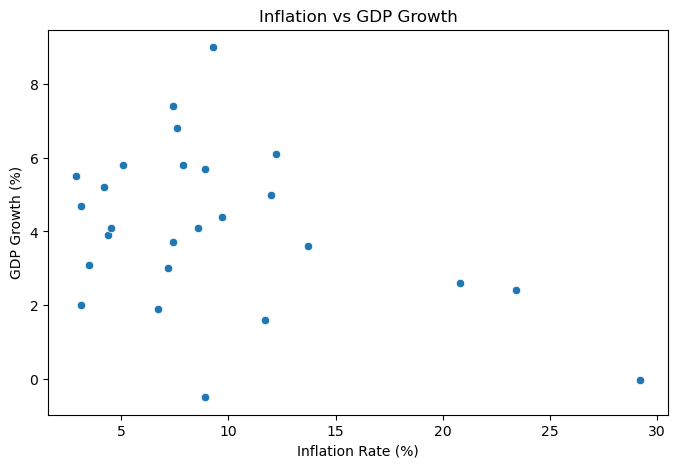

In [57]:
# Inflation vs GDP Growth
# Did higher inflation coincide with lower GDP growth?
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="inflation_cpi_pct",
    y="gdp_growth_pct")
plt.title("Inflation vs GDP Growth")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("GDP Growth (%)")
plt.show()

In [59]:
# Calculate correlation
inflation_growth_corr = df[
    ["inflation_cpi_pct", "gdp_growth_pct"]
].corr()
inflation_growth_corr

,inflation_cpi_pct,gdp_growth_pct
inflation_cpi_pct,1.00,-0.37
gdp_growth_pct,-0.37,1.00


Interpretation: A correlation of -0.37 indicates a moderate negative relationship, meaning higher inflation generally coincided with lower GDP growth in the dataset.

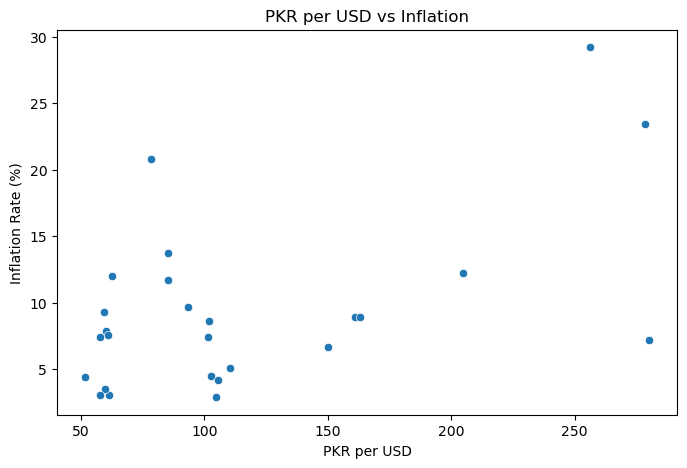

In [62]:
# Exchange Rate & Inflation
# Did PKR depreciation coincide with higher inflation?
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="pkr_per_usd",
    y="inflation_cpi_pct")
plt.title("PKR per USD vs Inflation")
plt.xlabel("PKR per USD")
plt.ylabel("Inflation Rate (%)")
plt.show()

In [64]:
# Calculate correlation
exchange_inflation_corr = df[
    ["pkr_per_usd", "inflation_cpi_pct"]
].corr()
exchange_inflation_corr

,pkr_per_usd,inflation_cpi_pct
pkr_per_usd,1.00,0.53
inflation_cpi_pct,0.53,1.00


Interpretation: A correlation of 0.53 indicates a moderate positive relationship, meaning PKR depreciation generally coincided with higher inflation in the dataset.

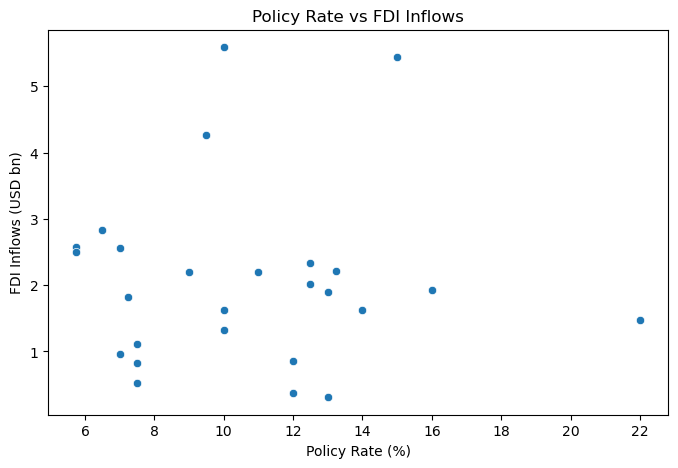

In [67]:
# Interest Rates & Investment
# Did higher interest rates coincide with lower FDI inflows?
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="policy_rate_pct",
    y="fdi_inflows_usd_bn")
plt.title("Policy Rate vs FDI Inflows")
plt.xlabel("Policy Rate (%)")
plt.ylabel("FDI Inflows (USD bn)")
plt.show()

In [69]:
# Calculate correlation
policy_fdi_corr = df[
    ["policy_rate_pct", "fdi_inflows_usd_bn"]
].corr()
policy_fdi_corr

,policy_rate_pct,fdi_inflows_usd_bn
policy_rate_pct,1.00,0.01
fdi_inflows_usd_bn,0.01,1.00


Interpretation: A correlation of 0.01 indicates almost no linear relationship between policy rates and FDI inflows in this dataset.

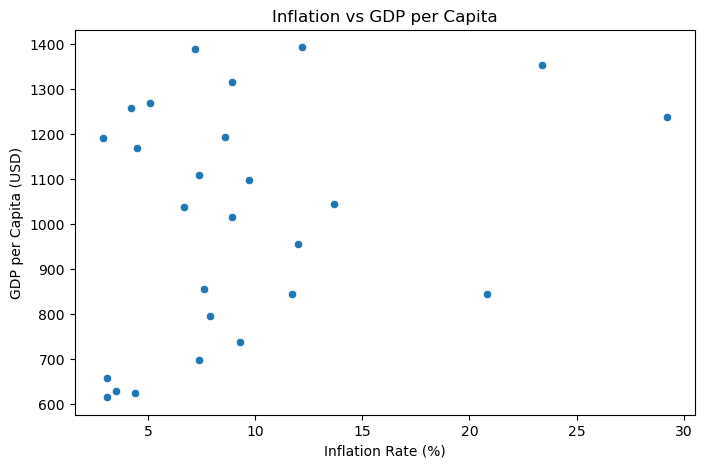

In [72]:
# Inflation & Consumer Purchasing Power
# Did higher inflation coincide with lower GDP per capita?
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="inflation_cpi_pct",
    y="gdp_per_capita_usd")
plt.title("Inflation vs GDP per Capita")
plt.xlabel("Inflation Rate (%)")
plt.ylabel("GDP per Capita (USD)")
plt.show()

In [74]:
# Calculate correlation
inflation_gdpcapita_corr = df[
    ["inflation_cpi_pct", "gdp_per_capita_usd"]
].corr()
inflation_gdpcapita_corr

,inflation_cpi_pct,gdp_per_capita_usd
inflation_cpi_pct,1.00,0.30
gdp_per_capita_usd,0.30,1.00


Interpretation: A correlation of 0.30 indicates a weak positive relationship, so higher inflation did not consistently coincide with lower GDP per capita in this dataset.

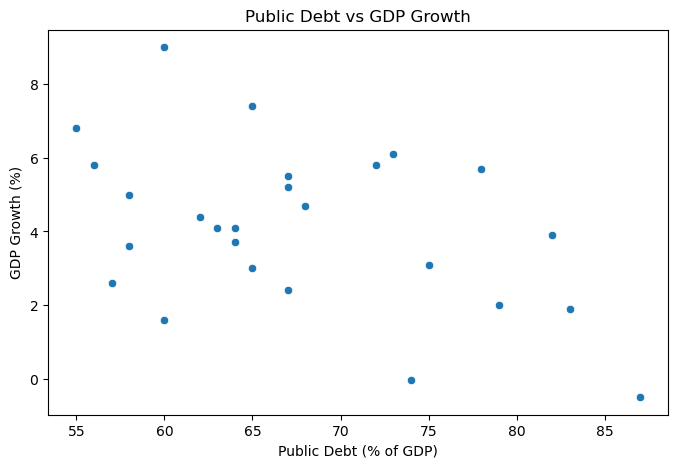

In [77]:
# Fiscal Policy & Economic Growth
# Did public debt increase during periods of weaker GDP growth?
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="public_debt_gdp_pct",
    y="gdp_growth_pct")
plt.title("Public Debt vs GDP Growth")
plt.xlabel("Public Debt (% of GDP)")
plt.ylabel("GDP Growth (%)")
plt.show()

In [79]:
# Calculate correlation
debt_growth_corr = df[
    ["public_debt_gdp_pct", "gdp_growth_pct"]
].corr()
debt_growth_corr

,public_debt_gdp_pct,gdp_growth_pct
public_debt_gdp_pct,1.00,-0.44
gdp_growth_pct,-0.44,1.00


Interpretation: A correlation of -0.44 indicates a moderate negative relationship, meaning higher public debt was generally associated with lower GDP growth in the dataset.

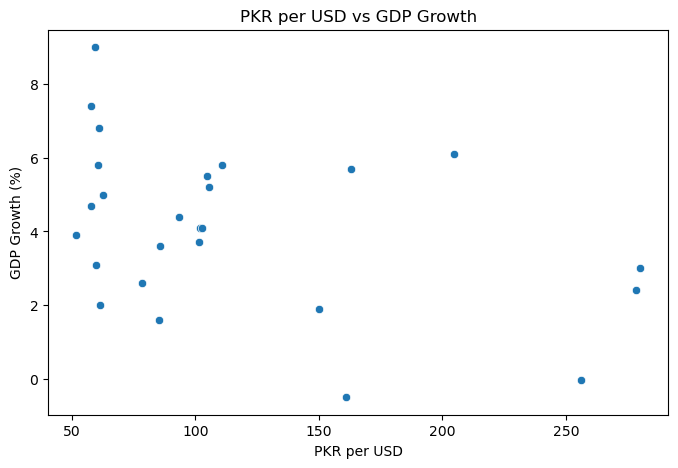

In [82]:
# Exchange Rate & Economic Growth
# Did PKR depreciation coincide with weaker economic growth?
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="pkr_per_usd",
    y="gdp_growth_pct")
plt.title("PKR per USD vs GDP Growth")
plt.xlabel("PKR per USD")
plt.ylabel("GDP Growth (%)")
plt.show()

In [84]:
# Calculate correlation
exchange_growth_corr = df[
    ["pkr_per_usd", "gdp_growth_pct"]
].corr()
exchange_growth_corr

,pkr_per_usd,gdp_growth_pct
pkr_per_usd,1.00,-0.41
gdp_growth_pct,-0.41,1.00


Interpretation: A correlation of -0.41 indicates a moderate negative relationship, meaning greater PKR depreciation generally coincided with lower GDP growth.

### PART 4 — Economic Growth & Business Activity Conclusion
Based on all the correlation results:
 - Inflation & policy rate: +0.73 → strong positive relationship.
 - Policy rate & GDP growth: -0.40 → moderate negative relationship.
 - Inflation & GDP growth: -0.37 → moderate negative relationship.
 - PKR depreciation & inflation: +0.53 → moderate positive relationship.
 - Policy rate & FDI: +0.01 → almost no relationship.
 - Inflation & GDP per capita: +0.30 → weak positive relationship.
 - Public debt & GDP growth: -0.44 → moderate negative relationship.
 - PKR depreciation & GDP growth: -0.41 → moderate negative relationship.
Overall Finding

The analysis suggests that inflation, interest rates, exchange-rate movements and public debt were associated with weaker economic growth, while higher inflation was strongly associated with tighter monetary policy. However, FDI showed almost no linear relationship with the policy rate in this dataset.

### Part 5 - Trade, Investment & External Sector

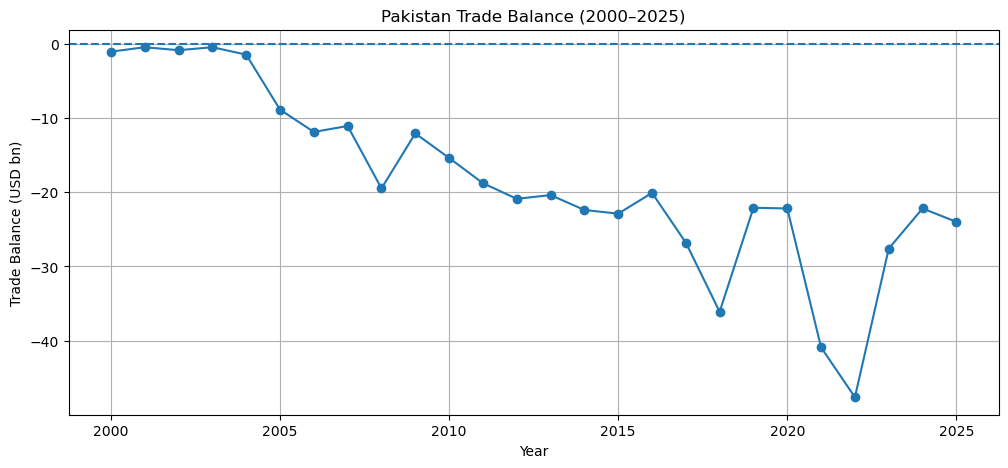

In [90]:
# Trade Balance Trend
# How has Pakistan's trade balance changed from 2000–2025?
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["trade_balance_usd_bn"],
    marker="o")
plt.axhline(0, linestyle="--")
plt.title("Pakistan Trade Balance (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Trade Balance (USD bn)")
plt.grid(True)
plt.show()

In [92]:
# Highest trade balance
highest_trade_balance = df.loc[
    df["trade_balance_usd_bn"].idxmax()]
# Lowest trade balance
lowest_trade_balance = df.loc[
    df["trade_balance_usd_bn"].idxmin()]
print("Highest Trade Balance:")
print(highest_trade_balance[["year", "trade_balance_usd_bn"]])

print("\nLowest Trade Balance:")
print(lowest_trade_balance[["year", "trade_balance_usd_bn"]])

Highest Trade Balance:
year                    2001
trade_balance_usd_bn   -0.50
Name: 1, dtype: object

Lowest Trade Balance:
year                     2022
trade_balance_usd_bn   -47.60
Name: 22, dtype: object


Interpretation: Pakistan had a trade deficit throughout the period, with the smallest deficit in 2001 at -$0.50 bn and the largest deficit in 2022 at -$47.60 bn, indicating substantial external trade imbalance in 2022.

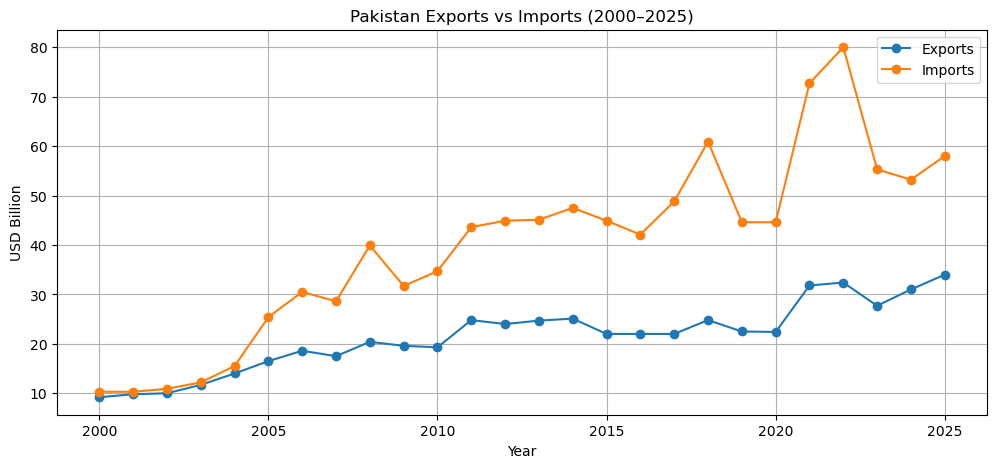

In [95]:
# Exports vs Imports
# How did exports and imports change over time and which grew faster?
plt.figure(figsize=(12, 5))
plt.plot(df["year"], df["exports_usd_bn"], marker="o", label="Exports")
plt.plot(df["year"], df["imports_usd_bn"], marker="o", label="Imports")
plt.title("Pakistan Exports vs Imports (2000–2025)")
plt.xlabel("Year")
plt.ylabel("USD Billion")
plt.legend()
plt.grid(True)
plt.show()

In [97]:
# Calculate percentage growth from 2000 to 2025
export_growth = (
    (df["exports_usd_bn"].iloc[-1] - df["exports_usd_bn"].iloc[0])
    / df["exports_usd_bn"].iloc[0]) * 100
import_growth = (
    (df["imports_usd_bn"].iloc[-1] - df["imports_usd_bn"].iloc[0])
    / df["imports_usd_bn"].iloc[0]) * 100
print(f"Export growth (2000–2025): {export_growth:.2f}%")
print(f"Import growth (2000–2025): {import_growth:.2f}%")

Export growth (2000–2025): 269.57%
Import growth (2000–2025): 463.11%


Interpretation: Exports increased by 269.57%, while imports increased much faster by 463.11%, helping explain the persistent and widening trade deficit.

In [100]:
# Highest and lowest FDI years
highest_fdi = df.loc[df["fdi_inflows_usd_bn"].idxmax()]
lowest_fdi = df.loc[df["fdi_inflows_usd_bn"].idxmin()]
print("Highest FDI:")
print(highest_fdi[["year", "fdi_inflows_usd_bn"]])

print("\nLowest FDI:")
print(lowest_fdi[["year", "fdi_inflows_usd_bn"]])

Highest FDI:
year                  2007
fdi_inflows_usd_bn    5.59
Name: 7, dtype: object

Lowest FDI:
year                  2000
fdi_inflows_usd_bn    0.31
Name: 0, dtype: object


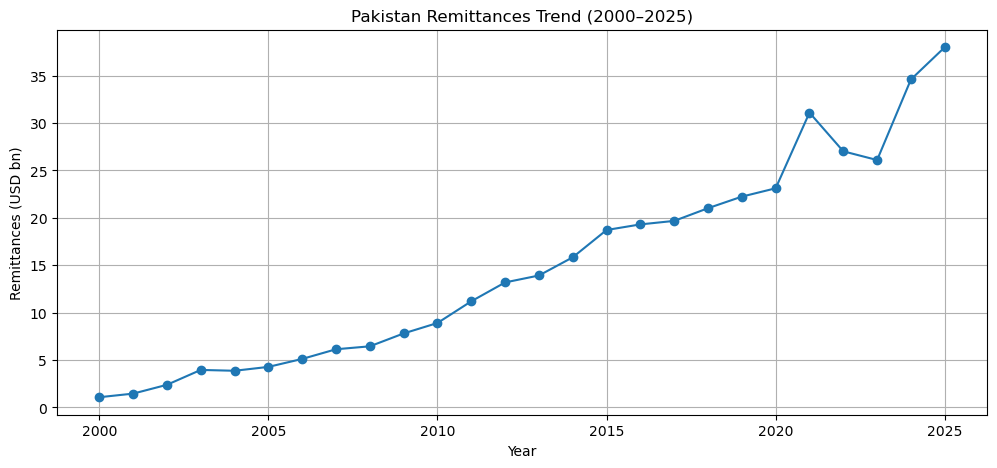

In [102]:
# Remittances & External Stability
# Did remittances increase over time and how important were they relative to GDP?
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["remittances_usd_bn"],
    marker="o")
plt.title("Pakistan Remittances Trend (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Remittances (USD bn)")
plt.grid(True)
plt.show()

In [104]:
# Compare remittances in 2000 and 2025
remittance_growth = (
    (df["remittances_usd_bn"].iloc[-1] - df["remittances_usd_bn"].iloc[0])
    / df["remittances_usd_bn"].iloc[0]) * 100
print(f"Remittance growth (2000–2025): {remittance_growth:.2f}%")

print("\nRemittances as % of GDP:")
print(df[["year", "remittances_gdp_pct"]].head())

Remittance growth (2000–2025): 3418.52%

Remittances as % of GDP:
   year  remittances_gdp_pct
0  2000                 1.08
1  2001                 1.44
2  2002                 2.22
3  2003                 3.40
4  2004                 3.05


Interpretation: Remittances increased by 3418.52% from 2000–2025, while their contribution to GDP also became much more significant, indicating growing importance for Pakistan's external finances.

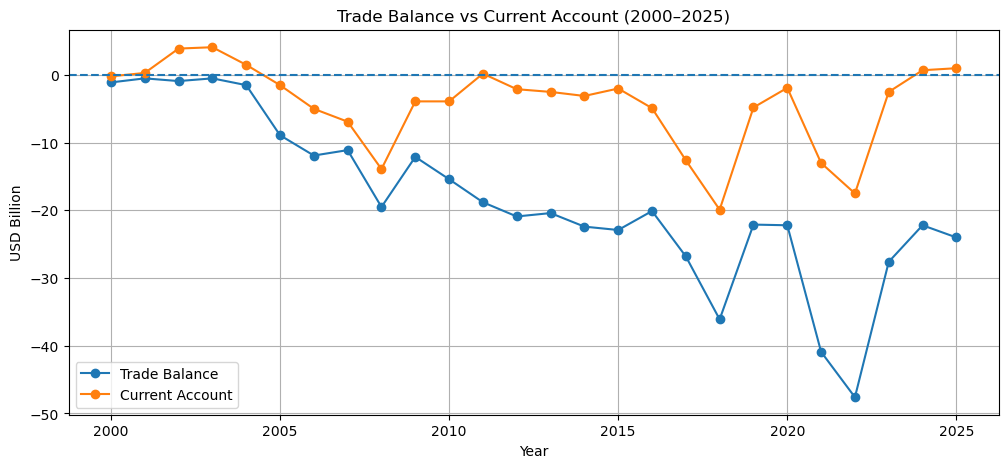

In [107]:
# Current Account & Trade Balance
# How did the current account and trade balance behave over 2000–2025?
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["trade_balance_usd_bn"],
    marker="o",
    label="Trade Balance")
plt.plot(
    df["year"],
    df["current_account_usd_bn"],
    marker="o",
    label="Current Account")
plt.axhline(0, linestyle="--")
plt.title("Trade Balance vs Current Account (2000–2025)")
plt.xlabel("Year")
plt.ylabel("USD Billion")
plt.legend()
plt.grid(True)
plt.show()

In [109]:
# Compare average trade balance and current account
print("Average Trade Balance:",
      df["trade_balance_usd_bn"].mean())

print("Average Current Account:",
      df["current_account_usd_bn"].mean())

Average Trade Balance: -18.4
Average Current Account: -4.246153846153846


Interpretation: The average trade balance was -18.4 dollar bn, while the average current account balance was -$4.25 bn, showing persistent external deficits over the period.

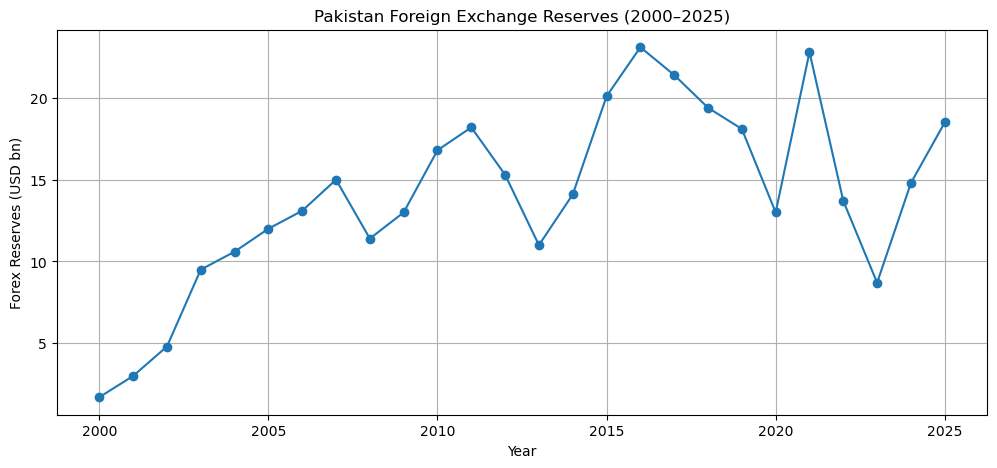

In [113]:
# Foreign Exchange Reserves Trend
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["forex_reserves_usd_bn"],
    marker="o")
plt.title("Pakistan Foreign Exchange Reserves (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Forex Reserves (USD bn)")
plt.grid(True)
plt.show()

In [115]:
# Highest and lowest forex reserves
highest_reserves = df.loc[df["forex_reserves_usd_bn"].idxmax()]
lowest_reserves = df.loc[df["forex_reserves_usd_bn"].idxmin()]
print("Highest Forex Reserves:")
print(highest_reserves[["year", "forex_reserves_usd_bn"]])

print("\nLowest Forex Reserves:")
print(lowest_reserves[["year", "forex_reserves_usd_bn"]])

Highest Forex Reserves:
year                     2016
forex_reserves_usd_bn   23.10
Name: 16, dtype: object

Lowest Forex Reserves:
year                     2000
forex_reserves_usd_bn    1.70
Name: 0, dtype: object


Interpretation: Forex reserves increased from $1.70 bn in 2000 to a peak of 23.10 dollar bn in 2016, showing a major improvement in external reserve strength during this period.

### Part 5 - Trade, Investment & External Sector Conclusion
 - Trade deficits remained persistent, averaging -18.4 dollar bn, with the largest deficit of -$47.6 bn in 2022.
 - Imports grew much faster than exports (463.11% vs 269.57%), contributing to the trade imbalance.
 - FDI peaked at 5.59 dollar bn in 2007, but remained relatively limited afterward.
 - Remittances grew dramatically by 3418.52%, becoming increasingly important to the economy.
 - Forex reserves improved strongly, reaching their highest level of 23.1 dollar bn in 2016.

Overall Finding

Pakistan's external sector was supported by strong remittance growth and periods of improved reserves, but persistent trade deficits—driven by imports growing faster than exports—remained a major external-sector challenge.

### Part 6 — Employment & Investment

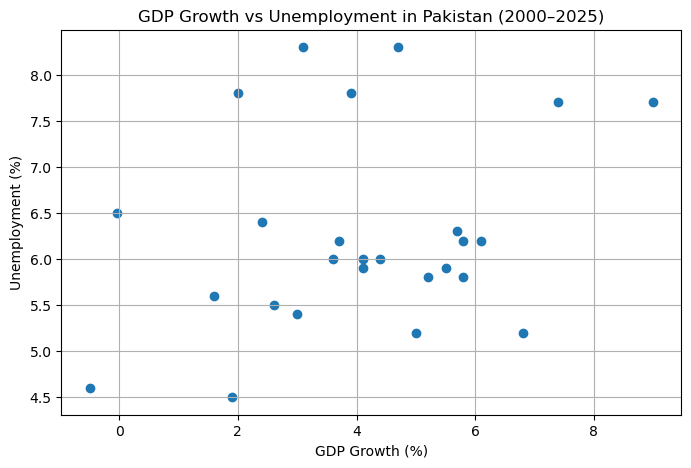

Correlation: 0.27
gdp_growth_category
High Growth          6.70
Low Growth           5.87
Moderate Growth      6.41
Recession/Negative   5.55
Name: unemployment_pct, dtype: float64


In [130]:
# GDP Growth vs Unemployment
plt.figure(figsize=(8, 5))
plt.scatter(
    df["gdp_growth_pct"],
    df["unemployment_pct"])
plt.xlabel("GDP Growth (%)")
plt.ylabel("Unemployment (%)")
plt.title("GDP Growth vs Unemployment in Pakistan (2000–2025)")
plt.grid(True)
plt.show()
# Correlation
correlation = df["gdp_growth_pct"].corr(df["unemployment_pct"])
print("Correlation:", round(correlation, 2))
# Average unemployment by GDP growth category
print(
    df.groupby("gdp_growth_category")["unemployment_pct"]
      .mean()
      .round(2))

Interpretation: GDP growth and unemployment show a weak positive correlation (≈ +0.27), indicating that unemployment did not consistently fall when GDP growth increased during 2000–2025.

In [136]:
# Investment vs GDP Growth
df.columns

Index(['year', 'gdp_usd_bn', 'gdp_growth_pct', 'gdp_per_capita_usd',
       'inflation_cpi_pct', 'unemployment_pct', 'remittances_usd_bn',
       'exports_usd_bn', 'imports_usd_bn', 'trade_balance_usd_bn',
       'forex_reserves_usd_bn', 'policy_rate_pct', 'pkr_per_usd',
       'public_debt_gdp_pct', 'current_account_usd_bn', 'fdi_inflows_usd_bn',
       'population_mn', 'literacy_rate_pct', 'agriculture_gdp_pct',
       'services_gdp_pct', 'industry_gdp_pct', 'tax_revenue_gdp_pct',
       'mobile_per_100', 'imf_program_active', 'key_events',
       'remittances_gdp_pct', 'exports_gdp_pct', 'imports_gdp_pct',
       'fdi_gdp_pct', 'gdp_growth_category', 'inflation_category', 'decade',
       'policy_rate_change'],
      dtype='object')

Interpretation: Total investment data is unavailable, so the relationship between investment and GDP growth cannot be directly analyzed using this dataset.

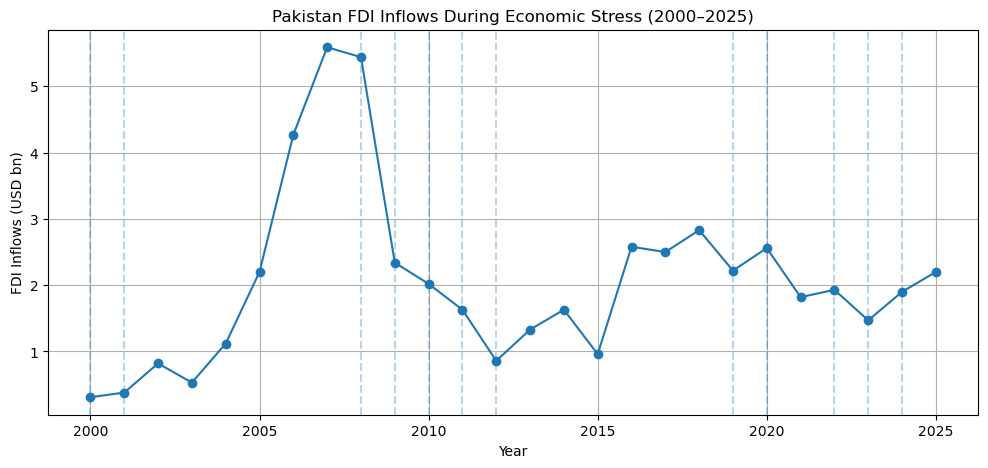

FDI During Economic Stress:
    year  inflation_cpi_pct  policy_rate_pct  gdp_growth_pct  \
0   2000               4.40            13.00            3.90   
1   2001               3.10            12.00            2.00   
8   2008              12.00            15.00            5.00   
9   2009              20.80            12.50            2.60   
10  2010              11.70            12.50            1.60   
11  2011              13.70            14.00            3.60   
12  2012               9.70            12.00            4.40   
19  2019               6.70            13.25            1.90   
20  2020               8.90             7.00           -0.50   
22  2022              12.20            16.00            6.10   
23  2023              29.20            22.00           -0.04   
24  2024              23.40            13.00            2.40   

    pkr_depreciation_pct  fdi_inflows_usd_bn  
0                    NaN                0.31  
1                  18.53                0.38 

In [139]:
# FDI During Economic Stress
# How did FDI inflows behave during periods of economic stress?
# Create PKR depreciation rate
df["pkr_depreciation_pct"] = (
    df["pkr_per_usd"].pct_change() * 100)
# Identify economic stress conditions
stress_years = df[
    (df["inflation_cpi_pct"] >= df["inflation_cpi_pct"].quantile(0.75)) |
    (df["policy_rate_pct"] >= df["policy_rate_pct"].quantile(0.75)) |
    (df["gdp_growth_pct"] <= df["gdp_growth_pct"].quantile(0.25)) |
    (df["pkr_depreciation_pct"] >= df["pkr_depreciation_pct"].quantile(0.75))]
# Plot FDI trend
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["fdi_inflows_usd_bn"],
    marker="o")
# Highlight stress years
for year in stress_years["year"]:
    plt.axvline(year, linestyle="--", alpha=0.3)
plt.title("Pakistan FDI Inflows During Economic Stress (2000–2025)")
plt.xlabel("Year")
plt.ylabel("FDI Inflows (USD bn)")
plt.grid(True)
plt.show()
# FDI during stress years
print("FDI During Economic Stress:")
print(
    stress_years[
        [
            "year",
            "inflation_cpi_pct",
            "policy_rate_pct",
            "gdp_growth_pct",
            "pkr_depreciation_pct",
            "fdi_inflows_usd_bn"]])

Interpretation: FDI was relatively high in 2008 at 5.44B dollar but declined sharply during subsequent stress periods, reaching $0.86B in 2012 and 1.47B dollar in 2023 amid high inflation, currency depreciation and weaker economic growth.

### Part 6 - Employment & Investment Conclusion
Overall, employment showed only a weak relationship with GDP growth, while FDI tended to be weaker during periods of economic stress; total investment relationships could not be tested due to data limitations.

### Part 7 — Major Economic Events

In [146]:
# Display major economic events
# Which major economic events occurred from 2000–2025 and how did key indicators behave around them?
print("Major Economic Events:")
print(
    df[
        ["year", "key_events"]
    ].to_string(index=False))

Major Economic Events:
 year                    key_events
 2000       Post-sanctions recovery
 2001     9/11 impact + debt relief
 2002         Economic reform start
 2003           Growth acceleration
 2004            High growth period
 2005            Record growth 8.6%
 2006               Growth slowdown
 2007         Global commodity boom
 2008       Global financial crisis
 2009          IMF bailout + floods
 2010               Floods recovery
 2011            Debt restructuring
 2012   IMF program + energy crisis
 2013          Political transition
 2014                   CPEC launch
 2015          Commodity price fall
 2016               Growth recovery
 2017          CPEC investment peak
 2018          Twin deficits crisis
 2019             IMF stabilization
 2020             COVID-19 pandemic
 2021            Post-COVID rebound
 2022     Record inflation + floods
 2023       IMF bailout + PKR crash
 2024  Stabilization + disinflation
 2025 Recovery + record remittances


In [148]:
# Analyze selected major events
selected_events = df[
    df["key_events"].notna() &
    (df["key_events"] != "")
][
    [
        "year",
        "key_events",
        "inflation_cpi_pct",
        "policy_rate_pct",
        "gdp_growth_pct",
        "pkr_per_usd",
        "fdi_inflows_usd_bn",
        "unemployment_pct"]]
selected_events

,year,key_events,inflation_cpi_pct,policy_rate_pct,gdp_growth_pct,pkr_per_usd,fdi_inflows_usd_bn,unemployment_pct
0,2000,Post-sanctions recovery,4.40,13.00,3.90,51.80,0.31,7.80
1,2001,9/11 impact + debt relief,3.10,12.00,2.00,61.40,0.38,7.80
2,2002,Economic reform start,3.50,7.50,3.10,59.70,0.82,8.30
3,2003,Growth acceleration,3.10,7.50,4.70,57.80,0.53,8.30
4,2004,High growth period,7.40,7.50,7.40,57.60,1.12,7.70
5,2005,Record growth 8.6%,9.30,9.00,9.00,59.50,2.20,7.70
6,2006,Growth slowdown,7.90,9.50,5.80,60.40,4.27,6.20
7,2007,Global commodity boom,7.60,10.00,6.80,60.90,5.59,5.20
8,2008,Global financial crisis,12.00,15.00,5.00,62.60,5.44,5.20
9,2009,IMF bailout + floods,20.80,12.50,2.60,78.50,2.34,5.50


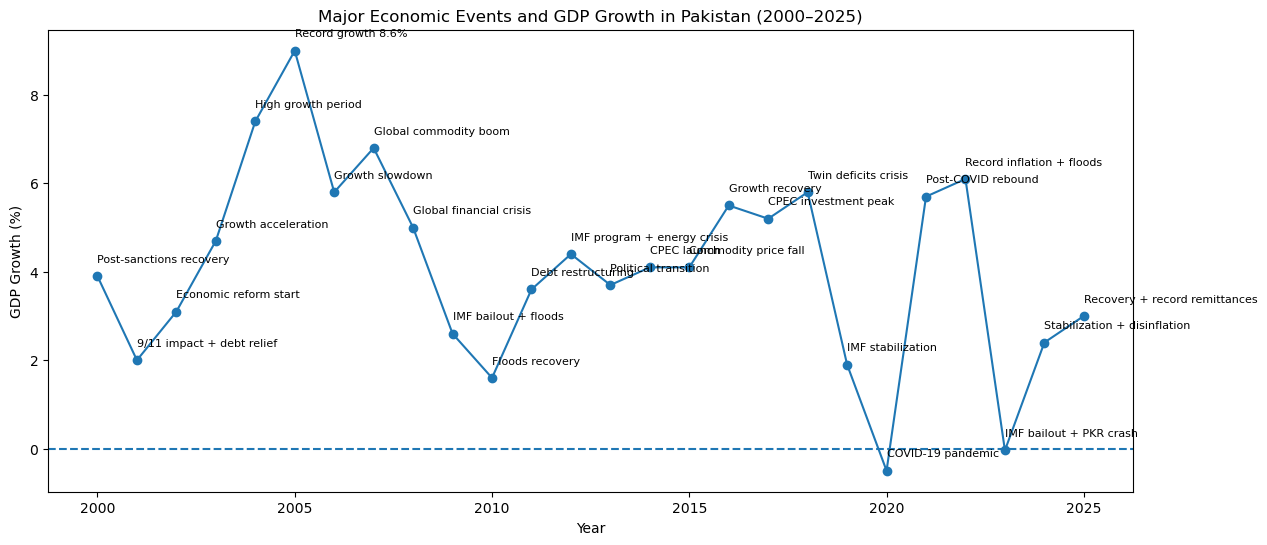

In [155]:
# Visualization
plt.figure(figsize=(14, 6))
plt.plot(
    df["year"],
    df["gdp_growth_pct"],
    marker="o")
for _, row in selected_events.iterrows():
    plt.annotate(
        row["key_events"],
        (row["year"], row["gdp_growth_pct"]),
        xytext=(0, 10),
        textcoords="offset points",
        fontsize=8)
plt.axhline(0, linestyle="--")
plt.title("Major Economic Events and GDP Growth in Pakistan (2000–2025)")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.show()

Interpretation: Major economic events were closely associated with substantial shifts in Pakistan’s macroeconomic indicators, with 2008–09 and especially 2023 standing out for high inflation, currency depreciation, elevated policy rates, weaker GDP growth and relatively low FDI.

In [157]:
# Compare IMF vs non-IMF periods
# How do economic indicators differ between IMF program and non-IMF periods?
imf_comparison = df.groupby("imf_program_active")[
    [   "inflation_cpi_pct",
        "gdp_growth_pct",
        "policy_rate_pct",
        "fdi_inflows_usd_bn",
        "pkr_per_usd"]].mean()
print(imf_comparison)

                    inflation_cpi_pct  gdp_growth_pct  policy_rate_pct  \
imf_program_active                                                       
0                                6.98            4.53            10.37   
1                               12.61            3.54            11.00   

                    fdi_inflows_usd_bn  pkr_per_usd  
imf_program_active                                   
0                                 1.85        88.12  
1                                 2.34       152.07  


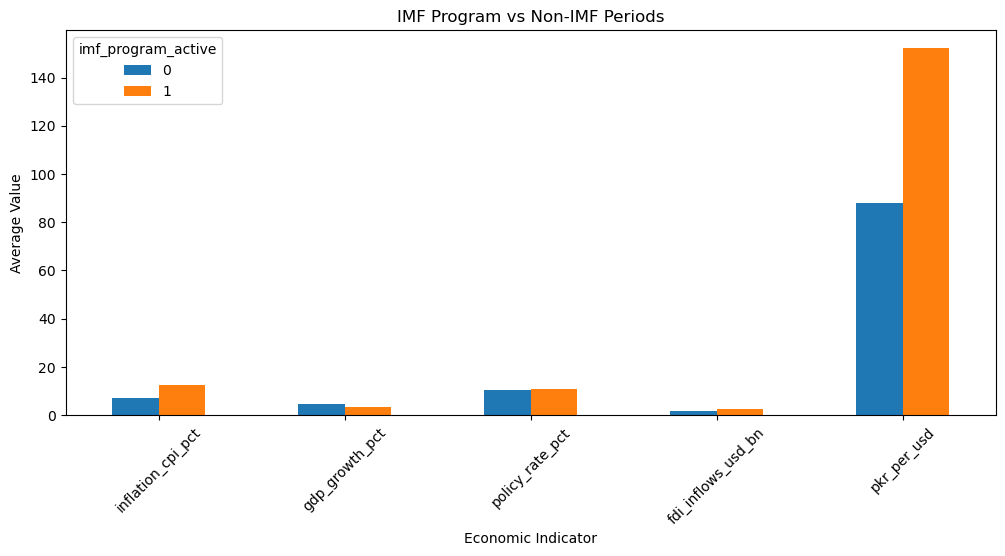

In [163]:
# Visualization
imf_comparison.T.plot(
    kind="bar",
    figsize=(12, 5))
plt.title("IMF Program vs Non-IMF Periods")
plt.xlabel("Economic Indicator")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

Interpretation: IMF-program periods had higher average inflation (12.61% vs 6.98%) and PKR/USD (152.07 vs 88.12), while GDP growth was lower (3.54% vs 4.53%) and FDI was higher (2.34 vs 1.85), showing a mixed economic pattern rather than uniformly weaker outcomes.

### Part 7 - Major Economic Events Conclusion
Major economic events and IMF periods were associated with noticeable differences in inflation, growth, interest rates, FDI and currency conditions, with IMF periods generally occurring alongside greater inflation and currency pressure.

### Part 8 - Economic Stress Analysis

In [171]:
# Economic Stress Score
# Create PKR depreciation rate
df["pkr_depreciation_pct"] = (
    df["pkr_per_usd"].pct_change() * 100)
# Calculate stress score
df["stress_score"] = (
    (df["inflation_cpi_pct"] >
     df["inflation_cpi_pct"].quantile(0.75)).astype(int)
    +
    (df["policy_rate_pct"] >
     df["policy_rate_pct"].quantile(0.75)).astype(int)
    +
    (df["pkr_depreciation_pct"] >
     df["pkr_depreciation_pct"].quantile(0.75)).astype(int)
    +
    (df["gdp_growth_pct"] <
     df["gdp_growth_pct"].quantile(0.25)).astype(int)
    +
    (df["unemployment_pct"] >
     df["unemployment_pct"].quantile(0.75)).astype(int))
# Rank years by stress score
stress_ranking = df[
    [
        "year",
        "stress_score",
        "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_depreciation_pct",
        "gdp_growth_pct",
        "unemployment_pct"]
].sort_values(
    "stress_score",
    ascending=False)
print("Economic Stress Ranking:")
print(stress_ranking.head(10))

Economic Stress Ranking:
    year  stress_score  inflation_cpi_pct  policy_rate_pct  \
23  2023             5              29.20            22.00   
9   2009             3              20.80            12.50   
24  2024             3              23.40            13.00   
22  2022             3              12.20            16.00   
1   2001             3               3.10            12.00   
19  2019             3               6.70            13.25   
8   2008             2              12.00            15.00   
10  2010             2              11.70            12.50   
11  2011             2              13.70            14.00   
0   2000             2               4.40            13.00   

    pkr_depreciation_pct  gdp_growth_pct  unemployment_pct  
23                 24.94           -0.04              6.50  
9                  25.40            2.60              5.50  
24                  8.79            2.40              6.40  
22                 25.78            6.10        

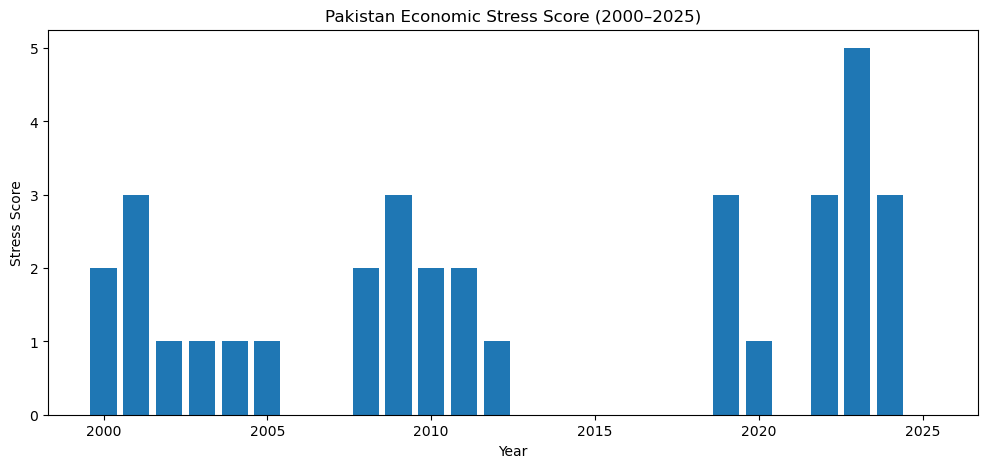

In [175]:
# Visualization
plt.figure(figsize=(12, 5))
plt.bar(
    stress_ranking["year"],
    stress_ranking["stress_score"])
plt.title("Pakistan Economic Stress Score (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Stress Score")
plt.show()

Interpretation: 2023 was the most economically stressed year with the maximum score of 5/5, while 2009, 2024, 2022, 2001 and 2019 followed with scores of 3/5.

In [178]:
# Stress-Year vs Stable-Year Comparison
# How does the highest-stress year compare with a relatively stable year?
comparison_years = df[
    df["year"].isin([2016, 2023])
][
    [
        "year",
        "inflation_cpi_pct",
        "policy_rate_pct",
        "gdp_growth_pct",
        "pkr_per_usd",
        "fdi_inflows_usd_bn",
        "unemployment_pct"]]
print("Stress Year vs Stable Year:")
print(comparison_years)

Stress Year vs Stable Year:
    year  inflation_cpi_pct  policy_rate_pct  gdp_growth_pct  pkr_per_usd  \
16  2016               2.90             5.75            5.50       104.60   
23  2023              29.20            22.00           -0.04       256.00   

    fdi_inflows_usd_bn  unemployment_pct  
16                2.58              5.90  
23                1.47              6.50  


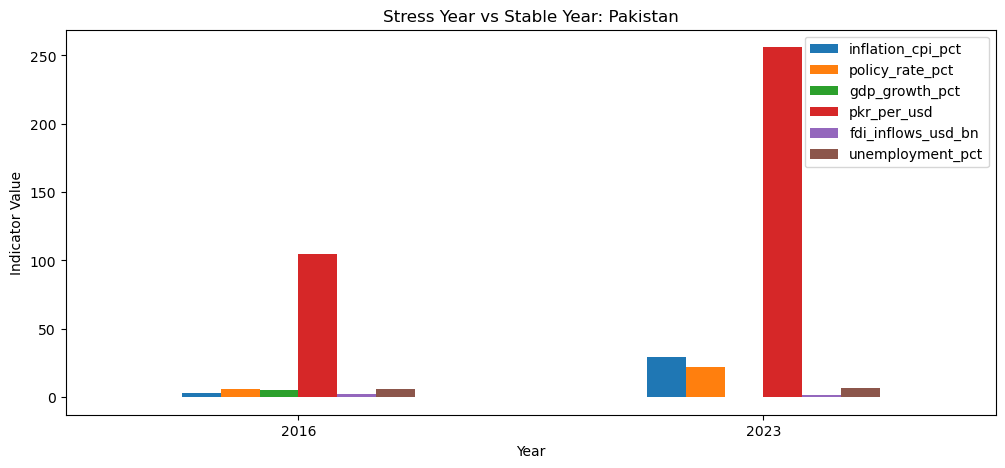

In [180]:
# Visualization
comparison_plot = comparison_years.set_index("year")
comparison_plot.plot(
    kind="bar",
    figsize=(12, 5))
plt.title("Stress Year vs Stable Year: Pakistan")
plt.xlabel("Year")
plt.ylabel("Indicator Value")
plt.xticks(rotation=0)
plt.show()

Interpretation: Compared with the stable year 2016, the stress year 2023 had dramatically higher inflation (29.2% vs 2.9%), policy rates (22% vs 5.75%) and PKR/USD (256 vs 104.6), alongside negative GDP growth, higher unemployment and lower FDI.

In [183]:
# Economic Recovery After Major Stress Periods
# How long did it take for GDP growth, inflation and investment to improve after major stress periods?
recovery_years = df[
    df["year"].isin([
        2009, 2010, 2011, 2012,
        2020, 2021,
        2023, 2024, 2025])][
    [   "year",
        "gdp_growth_pct",
        "inflation_cpi_pct",
        "fdi_inflows_usd_bn"]]
print("Economic Recovery:")
print(recovery_years)

Economic Recovery:
    year  gdp_growth_pct  inflation_cpi_pct  fdi_inflows_usd_bn
9   2009            2.60              20.80                2.34
10  2010            1.60              11.70                2.02
11  2011            3.60              13.70                1.63
12  2012            4.40               9.70                0.86
20  2020           -0.50               8.90                2.56
21  2021            5.70               8.90                1.82
23  2023           -0.04              29.20                1.47
24  2024            2.40              23.40                1.90
25  2025            3.00               7.20                2.20


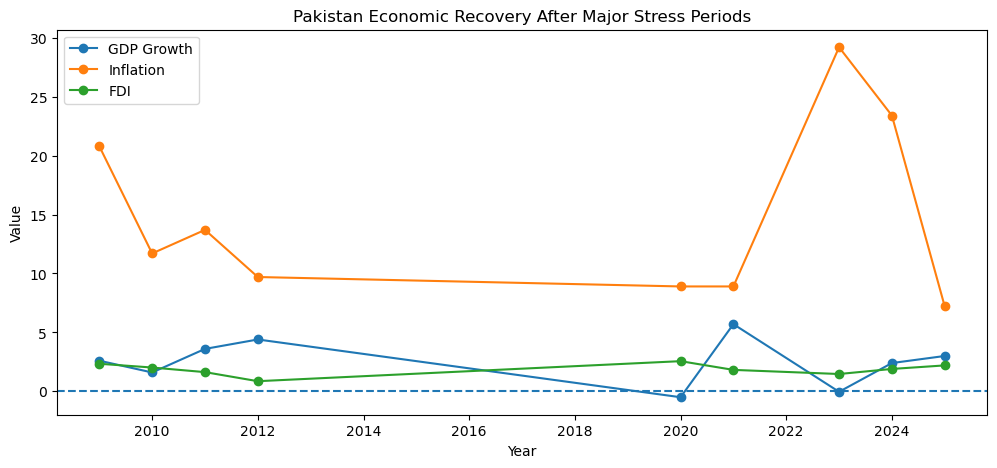

In [185]:
# Visualization
plt.figure(figsize=(12, 5))
plt.plot(
    recovery_years["year"],
    recovery_years["gdp_growth_pct"],
    marker="o",
    label="GDP Growth")
plt.plot(
    recovery_years["year"],
    recovery_years["inflation_cpi_pct"],
    marker="o",
    label="Inflation")
plt.plot(
    recovery_years["year"],
    recovery_years["fdi_inflows_usd_bn"],
    marker="o",
    label="FDI")
plt.axhline(0, linestyle="--")
plt.title("Pakistan Economic Recovery After Major Stress Periods")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.show()

Interpretation: After major stress periods, GDP growth generally recovered faster than inflation, with 2021 showing a strong GDP rebound after COVID-19 and 2025 showing the clearest recent recovery as inflation fell to 7.2%, GDP growth reached 3.0% and FDI rose to $2.20B.

### Part 8 - Economic Stress Analysis Conclusion
The analysis shows that 2023 was the most severe stress year, with the highest stress score and the weakest combination of GDP growth, inflation, currency value and FDI, while the recovery data shows improvement by 2025 as GDP growth reached 3.0%, inflation fell to 7.2%, and FDI increased to $2.20B.

### Part 9 - Business Impact

In [191]:
# Inflation → Business Costs
# How can rising inflation affect business costs and profitability?
# Select years with relatively high inflation
high_inflation = df[
    df["inflation_cpi_pct"] >= df["inflation_cpi_pct"].quantile(0.75)]
print("High Inflation Periods:")
print(
    high_inflation[
        [
            "year",
            "inflation_cpi_pct",
            "gdp_growth_pct",
            "policy_rate_pct"]])

High Inflation Periods:
    year  inflation_cpi_pct  gdp_growth_pct  policy_rate_pct
8   2008              12.00            5.00            15.00
9   2009              20.80            2.60            12.50
10  2010              11.70            1.60            12.50
11  2011              13.70            3.60            14.00
22  2022              12.20            6.10            16.00
23  2023              29.20           -0.04            22.00
24  2024              23.40            2.40            13.00


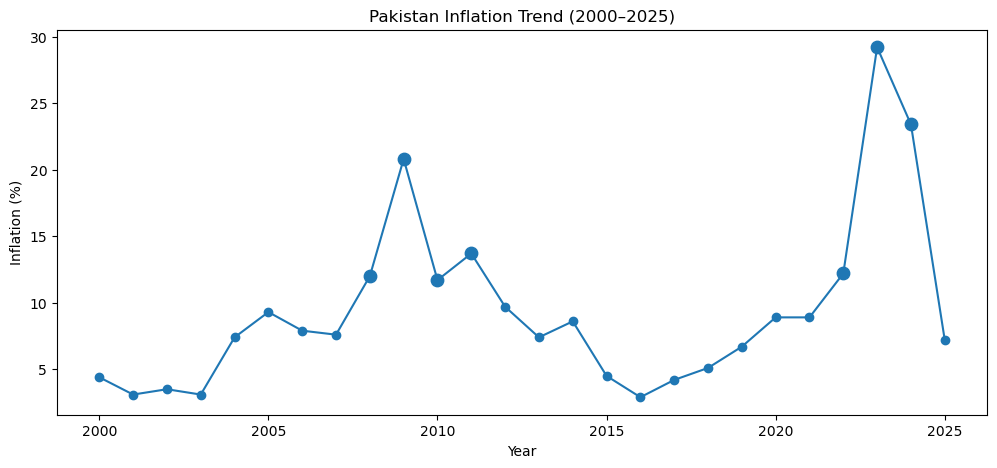

In [193]:
# Inflation → Business Costs
# Highlighting high-inflation periods
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["inflation_cpi_pct"],
    marker="o")
# Highlight high-inflation years
plt.scatter(
    high_inflation["year"],
    high_inflation["inflation_cpi_pct"],
    s=80)
plt.title("Pakistan Inflation Trend (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.show()

Interpretation: High inflation was concentrated in 2008–2011 and 2022–2024, peaking at 29.2% in 2023, indicating substantial periods of elevated cost pressure for businesses.

In [196]:
# Interest Rates → Financing
# How can rising policy rates affect business financing and profitability?
high_rate = df[
    df["policy_rate_pct"] >= df["policy_rate_pct"].quantile(0.75)]
print("High Policy Rate Periods:")
print(
    high_rate[
        [
            "year",
            "policy_rate_pct",
            "gdp_growth_pct",
            "inflation_cpi_pct"]])

High Policy Rate Periods:
    year  policy_rate_pct  gdp_growth_pct  inflation_cpi_pct
0   2000            13.00            3.90               4.40
8   2008            15.00            5.00              12.00
11  2011            14.00            3.60              13.70
19  2019            13.25            1.90               6.70
22  2022            16.00            6.10              12.20
23  2023            22.00           -0.04              29.20
24  2024            13.00            2.40              23.40


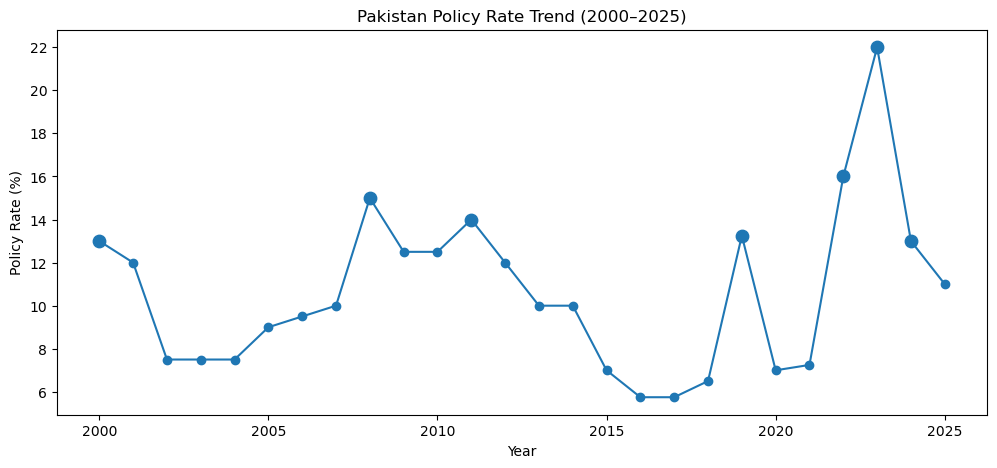

In [200]:
# Visualize it
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["policy_rate_pct"],
    marker="o")
plt.scatter(
    high_rate["year"],
    high_rate["policy_rate_pct"],
    s=80)
plt.title("Pakistan Policy Rate Trend (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Policy Rate (%)")
plt.show()

Interpretation: High policy-rate periods often coincided with elevated inflation and weaker GDP growth, with 2023 standing out at a 22% policy rate alongside 29.2% inflation and -0.04% GDP growth, indicating significant financing pressure for businesses.

In [203]:
# Exchange Rate → Import-Dependent Business
# How can PKR depreciation affect an import-dependent business?
# Identify years with high PKR depreciation
high_depreciation = df[
    df["pkr_depreciation_pct"] >=
    df["pkr_depreciation_pct"].quantile(0.75)]
print("High PKR Depreciation Periods:")
print(
    high_depreciation[
        [
            "year",
            "pkr_per_usd",
            "pkr_depreciation_pct",
            "inflation_cpi_pct",
            "gdp_growth_pct"]])

High PKR Depreciation Periods:
    year  pkr_per_usd  pkr_depreciation_pct  inflation_cpi_pct  gdp_growth_pct
1   2001        61.40                 18.53               3.10            2.00
9   2009        78.50                 25.40              20.80            2.60
12  2012        93.40                  9.24               9.70            4.40
19  2019       150.00                 35.62               6.70            1.90
22  2022       204.90                 25.78              12.20            6.10
23  2023       256.00                 24.94              29.20           -0.04
24  2024       278.50                  8.79              23.40            2.40


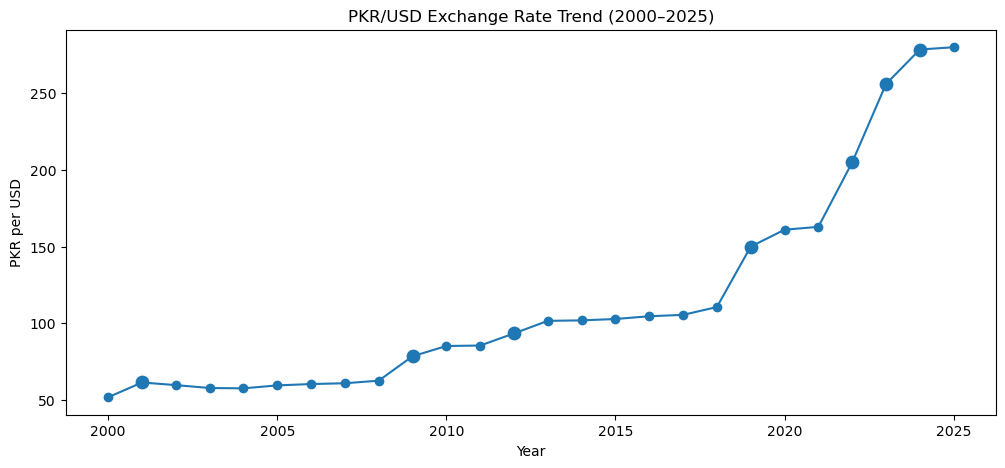

In [205]:
# Visualization
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["pkr_per_usd"],
    marker="o")
plt.scatter(
    high_depreciation["year"],
    high_depreciation["pkr_per_usd"],
    s=80)
plt.title("PKR/USD Exchange Rate Trend (2000–2025)")
plt.xlabel("Year")
plt.ylabel("PKR per USD")
plt.show()

Interpretation: PKR depreciation was particularly severe in 2009, 2019, 2022, and 2023, with the exchange rate reaching 256 PKR/USD in 2023, increasing the cost of imported inputs and putting pressure on production costs and profit margins.

In [208]:
# Exchange Rate → Export Business
# How can PKR depreciation affect an export-oriented business?
# Compare high PKR depreciation periods
print("High PKR Depreciation Periods:")
print(
    high_depreciation[
        [
            "year",
            "pkr_per_usd",
            "pkr_depreciation_pct",
            "exports_usd_bn",
            "gdp_growth_pct"]])

High PKR Depreciation Periods:
    year  pkr_per_usd  pkr_depreciation_pct  exports_usd_bn  gdp_growth_pct
1   2001        61.40                 18.53            9.80            2.00
9   2009        78.50                 25.40           19.60            2.60
12  2012        93.40                  9.24           24.00            4.40
19  2019       150.00                 35.62           22.50            1.90
22  2022       204.90                 25.78           32.40            6.10
23  2023       256.00                 24.94           27.70           -0.04
24  2024       278.50                  8.79           31.00            2.40


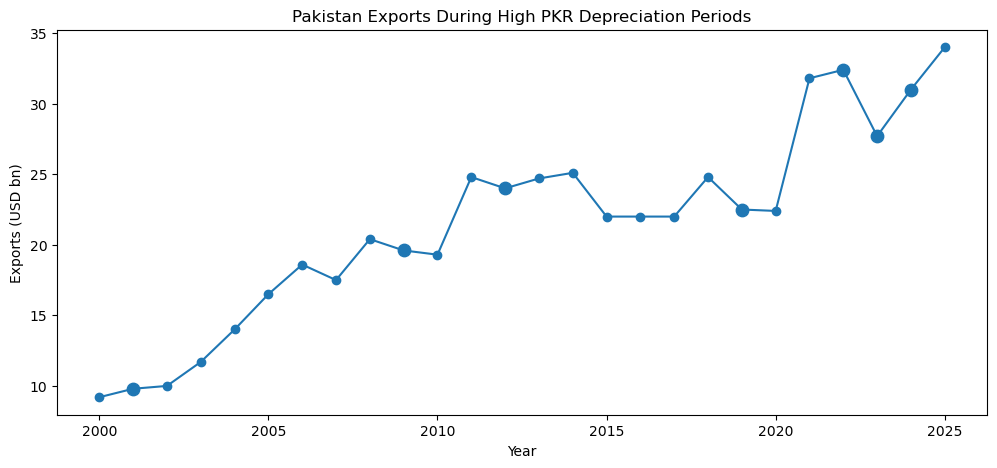

In [210]:
# Visualization
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["exports_usd_bn"],
    marker="o")
plt.scatter(
    high_depreciation["year"],
    high_depreciation["exports_usd_bn"],
    s=80)
plt.title("Pakistan Exports During High PKR Depreciation Periods")
plt.xlabel("Year")
plt.ylabel("Exports (USD bn)")
plt.show()

Interpretation: Despite significant PKR depreciation, exports increased from 9.8B dollar in 2001 to $31.0B in 2024, suggesting that currency depreciation may support export competitiveness, although other factors also influence export performance.

### Part 9 - Business Impact Conclusion
The analysis shows that high inflation and policy rates created significant cost and financing pressure for businesses, while PKR depreciation increased import costs but appeared to support export competitiveness, highlighting different impacts across import- and export-oriented businesses.

### Part 10 — Combined Economic Shock

Worst-Case Economic Scenario:
    year  inflation_cpi_pct  policy_rate_pct  pkr_per_usd  gdp_growth_pct  \
23  2023              29.20            22.00       256.00           -0.04   

    unemployment_pct  
23              6.50  


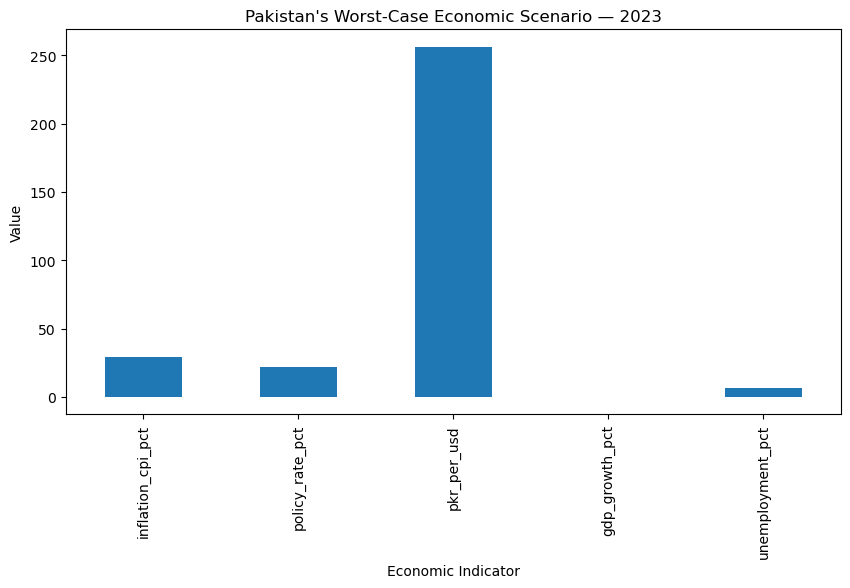

In [221]:
# Worst-Case Economic Scenario
# What happens to a business when inflation, interest rates and PKR depreciation rise while GDP growth and employment weaken?
worst_case_visual = df[
    df["year"] == 2023
][
    [
        "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_per_usd",
        "gdp_growth_pct",
        "unemployment_pct"]].T
print("Worst-Case Economic Scenario:")
print(worst_case)
worst_case_visual.columns = ["2023"]
worst_case_visual.plot(
    kind="bar",
    figsize=(10, 5),
    legend=False)
plt.title("Pakistan's Worst-Case Economic Scenario — 2023")
plt.xlabel("Economic Indicator")
plt.ylabel("Value")
plt.show()

Interpretation: In 2023, exceptionally high inflation (29.2%), policy rates (22%), and PKR/USD (256), combined with negative GDP growth (-0.04%) and 6.5% unemployment, created a highly challenging environment for businesses.

In [229]:
# Business Forecasting
# 2023 represents the worst-case economic environment identified earlier
forecast_stress = df[
    df["year"] == 2023][
    [
        "year",
        "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_per_usd",
        "gdp_growth_pct",
        "unemployment_pct"]]
print("Forecast Stress Conditions:")
print(forecast_stress)

Forecast Stress Conditions:
    year  inflation_cpi_pct  policy_rate_pct  pkr_per_usd  gdp_growth_pct  \
23  2023              29.20            22.00       256.00           -0.04   

    unemployment_pct  
23              6.50  


In [226]:
# Business Forecast Assumptions
forecast_assumptions = {
    "Revenue Growth": "Reconsider downward",
    "Sales Volume": "Expect demand pressure",
    "Pricing": "Review price increases",
    "Operating Costs": "Increase cost assumptions",
    "Interest Expense": "Increase financing cost assumptions",
    "Capital Expenditure": "Review or delay expansion",
    "Working Capital": "Allow for higher cash requirements",
    "Profit Margins": "Stress-test for compression"}
for assumption, action in forecast_assumptions.items():
    print(f"{assumption}: {action}")

Revenue Growth: Reconsider downward
Sales Volume: Expect demand pressure
Pricing: Review price increases
Operating Costs: Increase cost assumptions
Interest Expense: Increase financing cost assumptions
Capital Expenditure: Review or delay expansion
Working Capital: Allow for higher cash requirements
Profit Margins: Stress-test for compression


Interpretation: With 2023-like conditions continuing, businesses would need to lower revenue-growth expectations, prepare for higher costs and financing expenses, strengthen working capital, reconsider expansion and stress-test profit margins.

### Part 10 - Combined Economic Shock COnclusion
The analysis identifies 2023 as a severe economic stress scenario, where high inflation, policy rates, currency depreciation, negative GDP growth and elevated unemployment created significant business risks, highlighting the importance of revising forecasts and continuously monitoring key economic warning indicators.

### Part 11 - Managment Decision-Making

In [231]:
# Economic Risk Dashboard
# Which 5 economic indicators should management monitor regularly?
risk_indicators = [
    "inflation_cpi_pct",
    "policy_rate_pct",
    "pkr_per_usd",
    "gdp_growth_pct",
    "unemployment_pct"]
risk_dashboard = df[
    ["year"] + risk_indicators
].tail(5)
print("Economic Risk Dashboard — Recent 5 Years:")
print(risk_dashboard)

Economic Risk Dashboard — Recent 5 Years:
    year  inflation_cpi_pct  policy_rate_pct  pkr_per_usd  gdp_growth_pct  \
21  2021               8.90             7.25       162.90            5.70   
22  2022              12.20            16.00       204.90            6.10   
23  2023              29.20            22.00       256.00           -0.04   
24  2024              23.40            13.00       278.50            2.40   
25  2025               7.20            11.00       280.00            3.00   

    unemployment_pct  
21              6.30  
22              6.20  
23              6.50  
24              6.40  
25              5.40  


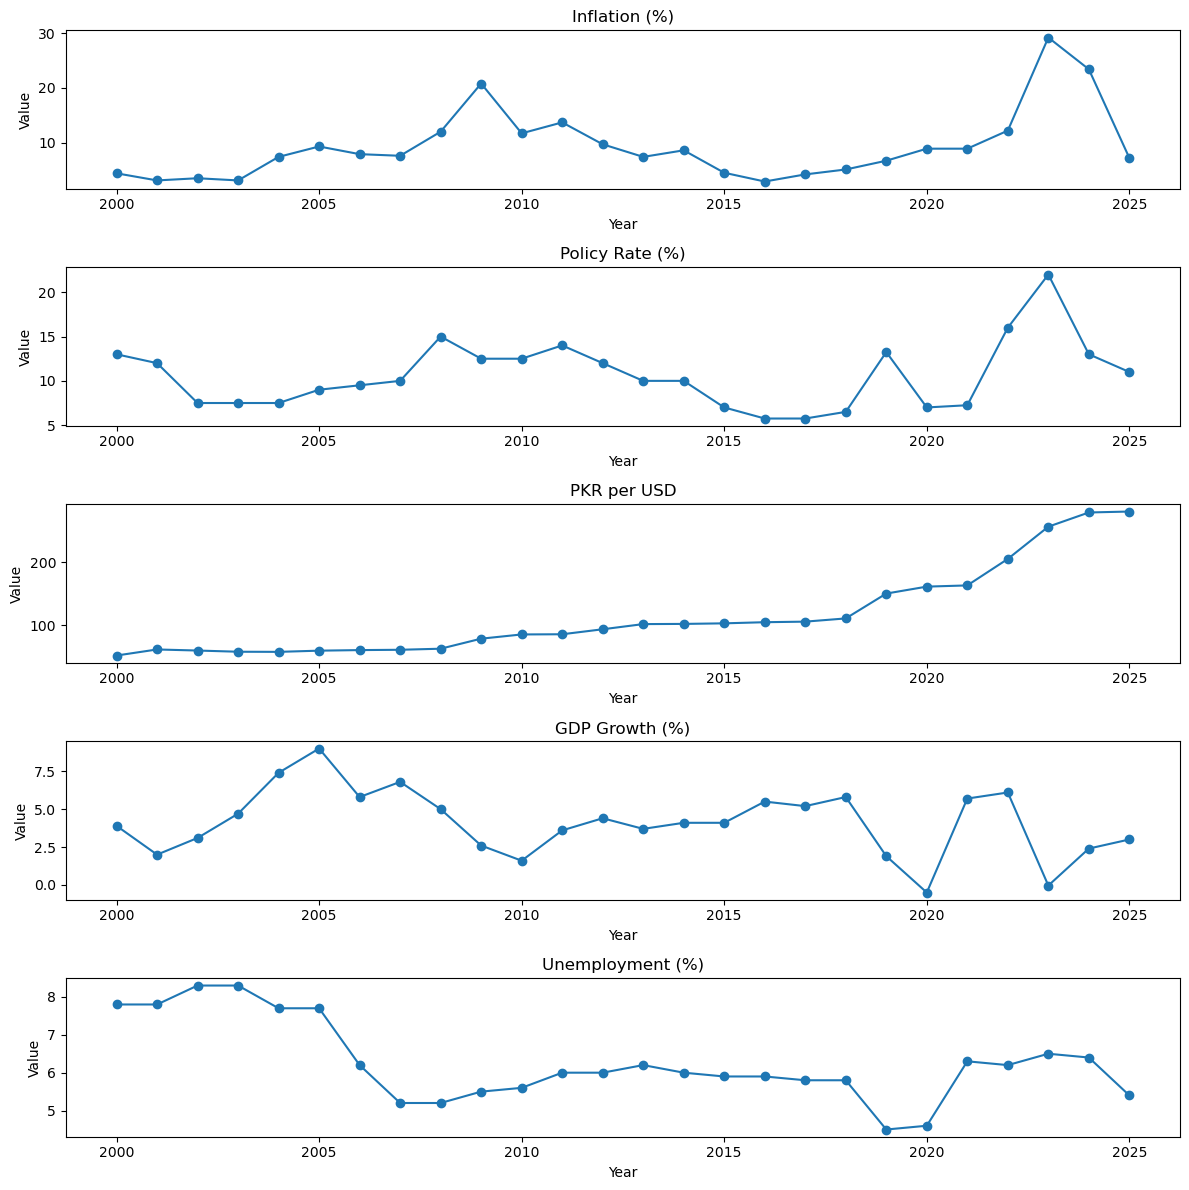

In [233]:
# Economic Risk Dashboard
fig, axes = plt.subplots(
    5, 1,
    figsize=(12, 12))
titles = [
    "Inflation (%)",
    "Policy Rate (%)",
    "PKR per USD",
    "GDP Growth (%)",
    "Unemployment (%)"]
for ax, indicator, title in zip(
    axes,
    risk_indicators,
    titles):
    ax.plot(
        df["year"],
        df[indicator],
        marker="o")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel("Value")
plt.tight_layout()
plt.show()

Interpretation: The dashboard shows 2023 as the key warning year, with inflation peaking at 29.2%, policy rate at 22%, GDP growth turning negative and unemployment reaching 6.5%, while conditions improved by 2025.

In [236]:
# Early Warning Indicators
# Which economic indicators could act as early warning signals of worsening business conditions?
early_warning = df[
    (df["inflation_cpi_pct"] >= df["inflation_cpi_pct"].quantile(0.75)) |
    (df["policy_rate_pct"] >= df["policy_rate_pct"].quantile(0.75)) |
    (df["pkr_depreciation_pct"] >= df["pkr_depreciation_pct"].quantile(0.75)) |
    (df["gdp_growth_pct"] <= df["gdp_growth_pct"].quantile(0.25)) |
    (df["unemployment_pct"] >= df["unemployment_pct"].quantile(0.75))]
print("Early Warning Periods:")
print(
    early_warning[
        [
            "year",
            "inflation_cpi_pct",
            "policy_rate_pct",
            "pkr_depreciation_pct",
            "gdp_growth_pct",
            "unemployment_pct"]])

Early Warning Periods:
    year  inflation_cpi_pct  policy_rate_pct  pkr_depreciation_pct  \
0   2000               4.40            13.00                   NaN   
1   2001               3.10            12.00                 18.53   
2   2002               3.50             7.50                 -2.77   
3   2003               3.10             7.50                 -3.18   
4   2004               7.40             7.50                 -0.35   
5   2005               9.30             9.00                  3.30   
8   2008              12.00            15.00                  2.79   
9   2009              20.80            12.50                 25.40   
10  2010              11.70            12.50                  8.54   
11  2011              13.70            14.00                  0.35   
12  2012               9.70            12.00                  9.24   
19  2019               6.70            13.25                 35.62   
20  2020               8.90             7.00                  7.33 

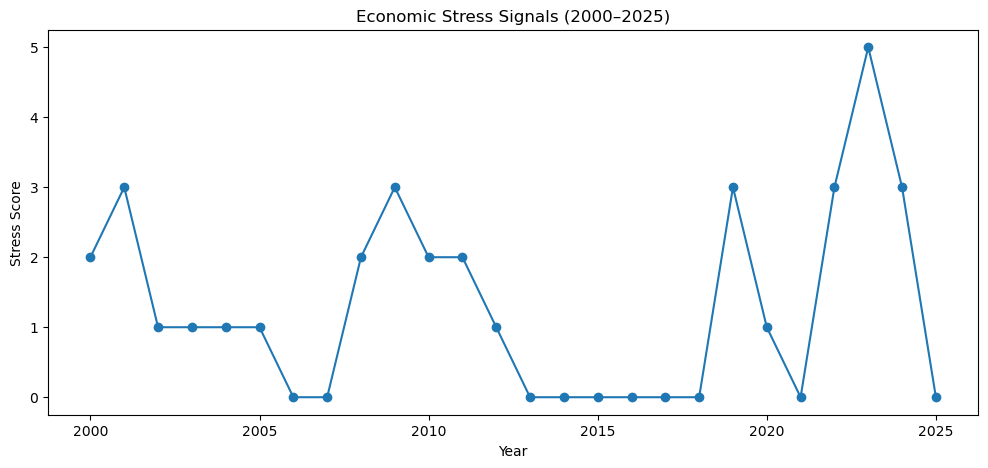

In [238]:
# Visualization
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["stress_score"],
    marker="o")
plt.title("Economic Stress Signals (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Stress Score")
plt.show()

Interpretation: The early warning indicators highlight recurring periods of economic vulnerability, with 2009, 2019, 2020 and especially 2022–2024 showing the strongest combination of high inflation, rising policy rates, currency depreciation and weak GDP growth, making them important warning periods for businesses.

In [250]:
# Management Response
# Use the highest-stress year identified earlier
management_year = df[
    df["year"] == 2023][[
        "year",
        "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_per_usd",
        "gdp_growth_pct",
        "unemployment_pct"]]
print("Economic Conditions:")
print(management_year)

Economic Conditions:
    year  inflation_cpi_pct  policy_rate_pct  pkr_per_usd  gdp_growth_pct  \
23  2023              29.20            22.00       256.00           -0.04   

    unemployment_pct  
23              6.50  


In [253]:
# Extract 2023 values
row = management_year.iloc[0]
print("Management Recommendations:")
if row["inflation_cpi_pct"] > 20:
    print("1. Control operating costs and review pricing strategy.")
if row["policy_rate_pct"] > 15:
    print("2. Reduce unnecessary borrowing and manage financing costs.")
if row["pkr_per_usd"] > 200:
    print("3. Manage foreign exchange exposure and import costs.")
if row["gdp_growth_pct"] <= 0:
    print("4. Protect cash flow and prepare for weaker demand.")
if row["unemployment_pct"] > 6:
    print("5. Strengthen scenario planning and monitor consumer demand.")

Management Recommendations:
1. Control operating costs and review pricing strategy.
2. Reduce unnecessary borrowing and manage financing costs.
3. Manage foreign exchange exposure and import costs.
4. Protect cash flow and prepare for weaker demand.
5. Strengthen scenario planning and monitor consumer demand.


In [255]:
# Scenario Analysis
# How could business performance change under stable, moderate-stress, and severe-stress economic conditions?
# Stable economy → 2016, Moderate stress → 2022, Severe stress → 2023
scenario_years = {
    "Stable Economy": 2016,
    "Moderate Stress": 2022,
    "Severe Stress": 2023}
scenario_data = df[
    df["year"].isin(scenario_years.values())][
    [   "year",
        "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_per_usd",
        "gdp_growth_pct",
        "unemployment_pct",
        "fdi_inflows_usd_bn"]].copy()
scenario_data["Scenario"] = scenario_data["year"].map(
    {v: k for k, v in scenario_years.items()})
scenario_data = scenario_data[
    [   "Scenario",
        "year",
        "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_per_usd",
        "gdp_growth_pct",
        "unemployment_pct",
        "fdi_inflows_usd_bn"]]
print("Scenario Analysis:")
print(scenario_data.to_string(index=False))

Scenario Analysis:
       Scenario  year  inflation_cpi_pct  policy_rate_pct  pkr_per_usd  gdp_growth_pct  unemployment_pct  fdi_inflows_usd_bn
 Stable Economy  2016               2.90             5.75       104.60            5.50              5.90                2.58
Moderate Stress  2022              12.20            16.00       204.90            6.10              6.20                1.93
  Severe Stress  2023              29.20            22.00       256.00           -0.04              6.50                1.47


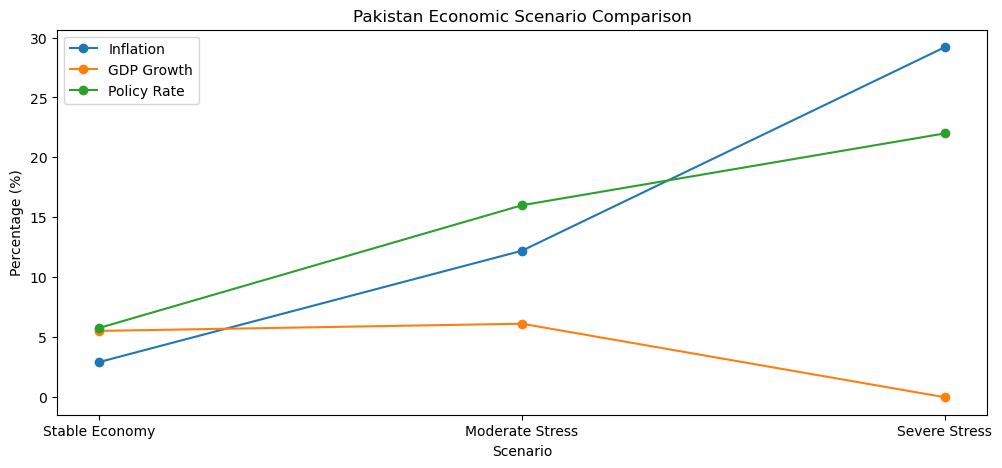

In [257]:
# Visualize it
plt.figure(figsize=(12, 5))
plt.plot(
    scenario_data["Scenario"],
    scenario_data["inflation_cpi_pct"],
    marker="o",
    label="Inflation")
plt.plot(
    scenario_data["Scenario"],
    scenario_data["gdp_growth_pct"],
    marker="o",
    label="GDP Growth")
plt.plot(
    scenario_data["Scenario"],
    scenario_data["policy_rate_pct"],
    marker="o",
    label="Policy Rate")
plt.title("Pakistan Economic Scenario Comparison")
plt.xlabel("Scenario")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()

Interpretation: As economic stress increased from 2016 to 2023, inflation rose from 2.9% to 29.2%, policy rates from 5.75% to 22%, and PKR/USD from 104.6 to 256, while GDP growth fell from 5.5% to -0.04% and FDI declined from $2.58B to 1.47B dollar.

### Part 11 - Managment Decision-Making Conclusion
The analysis shows that worsening macroeconomic conditions were associated with higher inflation, financing and currency pressure, weaker economic growth and lower FDI, highlighting the need for stronger cost, liquidity, currency and risk management.

### Part 12 - Final Analysis Conclusions

In [270]:
# Q21. Major Economic Patterns
# What were the major economic patterns in Pakistan from 2000–2025?
major_patterns = df[
    [   "year",
        "inflation_cpi_pct",
        "policy_rate_pct",
        "gdp_growth_pct",
        "pkr_per_usd",
        "fdi_inflows_usd_bn",
        "unemployment_pct"]]
# Identify key maximum and minimum values
print("Highest Inflation:")
print(
    df.loc[
        df["inflation_cpi_pct"].idxmax(),
        ["year", "inflation_cpi_pct"]])
print("\nHighest GDP Growth:")
print(
    df.loc[
        df["gdp_growth_pct"].idxmax(),
        ["year", "gdp_growth_pct"]])
print("\nLowest GDP Growth:")
print(
    df.loc[
        df["gdp_growth_pct"].idxmin(),
        ["year", "gdp_growth_pct"]])
print("\nHighest Policy Rate:")
print(
    df.loc[
        df["policy_rate_pct"].idxmax(),
        ["year", "policy_rate_pct"]])
print("\nHighest PKR/USD:")
print(
    df.loc[
        df["pkr_per_usd"].idxmax(),
        ["year", "pkr_per_usd"]])
print("\nHighest FDI:")
print(
    df.loc[
        df["fdi_inflows_usd_bn"].idxmax(),
        ["year", "fdi_inflows_usd_bn"]])

Highest Inflation:
year                 2023
inflation_cpi_pct   29.20
Name: 23, dtype: object

Highest GDP Growth:
year              2005
gdp_growth_pct    9.00
Name: 5, dtype: object

Lowest GDP Growth:
year              2020
gdp_growth_pct   -0.50
Name: 20, dtype: object

Highest Policy Rate:
year               2023
policy_rate_pct   22.00
Name: 23, dtype: object

Highest PKR/USD:
year            2025
pkr_per_usd   280.00
Name: 25, dtype: object

Highest FDI:
year                  2007
fdi_inflows_usd_bn    5.59
Name: 7, dtype: object


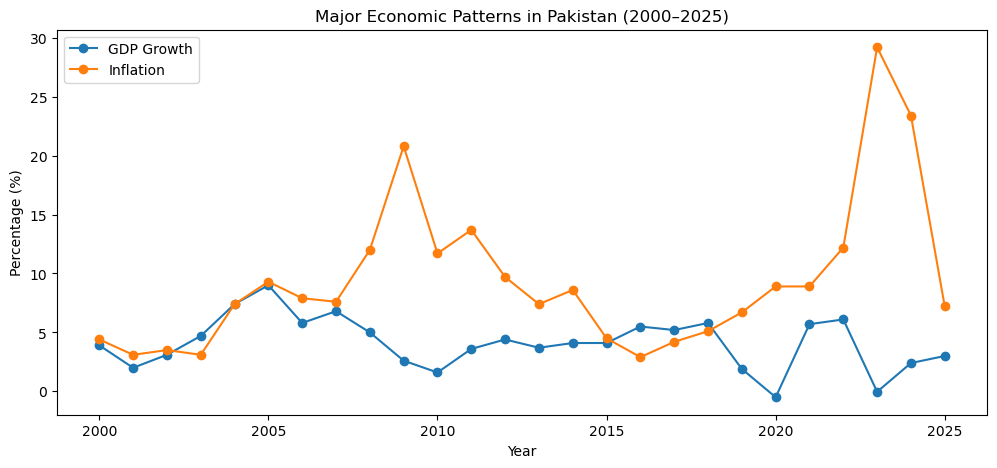

In [272]:
# Major Economic Indicators - Visualize it
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["gdp_growth_pct"],
    marker="o",
    label="GDP Growth")
plt.plot(
    df["year"],
    df["inflation_cpi_pct"],
    marker="o",
    label="Inflation")
plt.title("Major Economic Patterns in Pakistan (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()

Interpretation: Pakistan’s economy experienced strong growth in the mid-2000s, with GDP growth peaking at 9.0% in 2005 and FDI at $5.59B in 2007, while economic stress intensified later, with inflation and the policy rate peaking in 2023 and the PKR/USD reaching 280 in 2025.

In [275]:
# Q22. Most Challenging Economic Periods
# Which periods were the most difficult for Pakistan's economy?
challenging_periods = df[
    [   "year",
        "stress_score",
        "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_depreciation_pct",
        "gdp_growth_pct",
        "unemployment_pct"]
].sort_values(
    "stress_score",
    ascending=False)
print("Most Challenging Economic Periods:")
print(challenging_periods.head(10).to_string(index=False))

Most Challenging Economic Periods:
 year  stress_score  inflation_cpi_pct  policy_rate_pct  pkr_depreciation_pct  gdp_growth_pct  unemployment_pct
 2023             5              29.20            22.00                 24.94           -0.04              6.50
 2009             3              20.80            12.50                 25.40            2.60              5.50
 2024             3              23.40            13.00                  8.79            2.40              6.40
 2022             3              12.20            16.00                 25.78            6.10              6.20
 2001             3               3.10            12.00                 18.53            2.00              7.80
 2019             3               6.70            13.25                 35.62            1.90              4.50
 2008             2              12.00            15.00                  2.79            5.00              5.20
 2010             2              11.70            12.50              

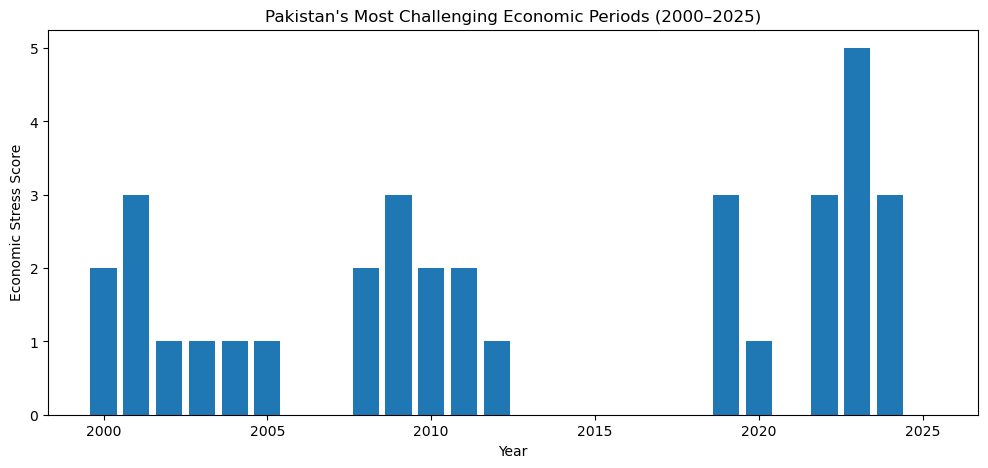

In [277]:
# Visualize Most Challenging Economic Periods
plt.figure(figsize=(12, 5))
plt.bar(
    challenging_periods["year"],
    challenging_periods["stress_score"])
plt.title("Pakistan's Most Challenging Economic Periods (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Economic Stress Score")
plt.show()

Interpretation: 2023 was clearly the most challenging year with a stress score of 5, driven by 29.2% inflation, a 22% policy rate, 24.94% PKR depreciation and negative GDP growth, while 2009, 2022, 2024 and 2019 also showed elevated economic stress.

In [280]:
# Correlation Analysis
# Which relationships between the major indicators were strongest?
correlation_cols = [
    "inflation_cpi_pct",
    "policy_rate_pct",
    "gdp_growth_pct",
    "pkr_per_usd",
    "unemployment_pct",
    "fdi_inflows_usd_bn"]
correlation_matrix = df[correlation_cols].corr()
print("Correlation Matrix:")
print(correlation_matrix.round(2))

Correlation Matrix:
                    inflation_cpi_pct  policy_rate_pct  gdp_growth_pct  \
inflation_cpi_pct                1.00             0.73           -0.37   
policy_rate_pct                  0.73             1.00           -0.40   
gdp_growth_pct                  -0.37            -0.40            1.00   
pkr_per_usd                      0.53             0.38           -0.41   
unemployment_pct                -0.20            -0.11            0.27   
fdi_inflows_usd_bn               0.10             0.01            0.27   

                    pkr_per_usd  unemployment_pct  fdi_inflows_usd_bn  
inflation_cpi_pct          0.53             -0.20                0.10  
policy_rate_pct            0.38             -0.11                0.01  
gdp_growth_pct            -0.41              0.27                0.27  
pkr_per_usd                1.00             -0.33               -0.05  
unemployment_pct          -0.33              1.00               -0.59  
fdi_inflows_usd_bn        -0.

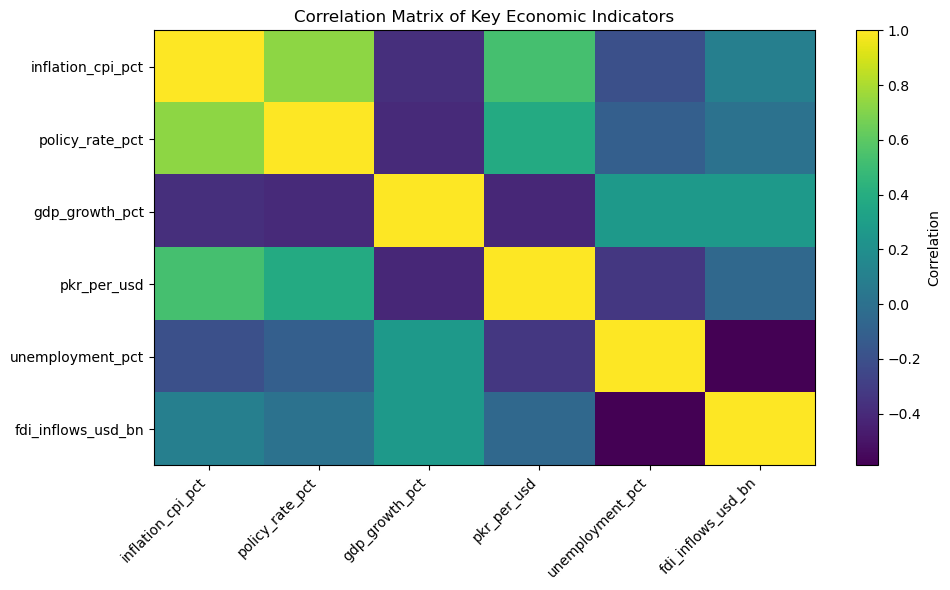

In [282]:
plt.figure(figsize=(10, 6))
plt.imshow(correlation_matrix, aspect="auto")
plt.xticks(
    range(len(correlation_cols)),
    correlation_cols,
    rotation=45,
    ha="right")
plt.yticks(
    range(len(correlation_cols)),
    correlation_cols)
plt.title("Correlation Matrix of Key Economic Indicators")
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.show()

Interpretation: The strongest relationships were positive between inflation and policy rate (0.73) and negative between unemployment and FDI (-0.59), while policy rate and GDP growth (-0.40) and PKR/USD and GDP growth (-0.41) showed moderate negative associations; these are correlations and do not establish causation.

In [285]:
# Pakistani Business Environment
# How do Inflation -> Interest Rates -> Exchange Rate -> GDP -> Investment connect to business conditions?
business_environment = df[
    [   "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_per_usd",
        "gdp_growth_pct",
        "fdi_inflows_usd_bn"]].mean()
print("Average Economic Indicators (2000–2025):")
print(business_environment.round(2))

Average Economic Indicators (2000–2025):
inflation_cpi_pct      9.36
policy_rate_pct       10.63
pkr_per_usd          115.18
gdp_growth_pct         4.11
fdi_inflows_usd_bn     2.06
dtype: float64


In [287]:
# Correlations with GDP Growth and FDI
business_corr = df[
    [   "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_per_usd",
        "gdp_growth_pct",
        "fdi_inflows_usd_bn"]].corr()
print("Business Environment Correlations:")
print(
    business_corr[
        ["gdp_growth_pct", "fdi_inflows_usd_bn"]
    ].round(2))

Business Environment Correlations:
                    gdp_growth_pct  fdi_inflows_usd_bn
inflation_cpi_pct            -0.37                0.10
policy_rate_pct              -0.40                0.01
pkr_per_usd                  -0.41               -0.05
gdp_growth_pct                1.00                0.27
fdi_inflows_usd_bn            0.27                1.00


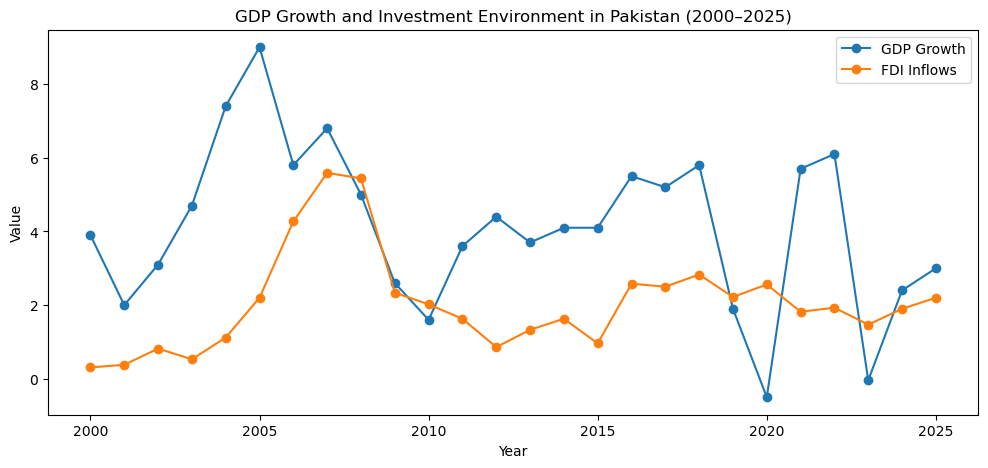

In [289]:
# Economic Conditions and Business Environment
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["gdp_growth_pct"],
    marker="o",
    label="GDP Growth")
plt.plot(
    df["year"],
    df["fdi_inflows_usd_bn"],
    marker="o",
    label="FDI Inflows")
plt.title("GDP Growth and Investment Environment in Pakistan (2000–2025)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.show()

Interpretation: From 2000–2025, higher inflation (-0.37), policy rates (-0.40) and PKR/USD (-0.41) were moderately associated with lower GDP growth, while FDI showed only a weak positive relationship with GDP growth (0.27), highlighting how macroeconomic pressure can be linked with a more challenging business environment.

In [300]:
# Final Management Recommendation
final_year = df.loc[
    df["stress_score"].idxmax()]
final_risk_summary = final_year[
    [   "year",
        "stress_score",
        "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_per_usd",
        "gdp_growth_pct",
        "fdi_inflows_usd_bn",
        "unemployment_pct"]]
print("Highest-Stress Economic Year:")
print(final_risk_summary)

Highest-Stress Economic Year:
year                   2023
stress_score              5
inflation_cpi_pct     29.20
policy_rate_pct       22.00
pkr_per_usd          256.00
gdp_growth_pct        -0.04
fdi_inflows_usd_bn     1.47
unemployment_pct       6.50
Name: 23, dtype: object


In [296]:
# Correlations with GDP Growth
risk_relationships = df[
    [   "inflation_cpi_pct",
        "policy_rate_pct",
        "pkr_per_usd",
        "gdp_growth_pct"]].corr()["gdp_growth_pct"].drop("gdp_growth_pct")
print("Relationships with GDP Growth:")
print(risk_relationships.round(2))

Relationships with GDP Growth:
inflation_cpi_pct   -0.37
policy_rate_pct     -0.40
pkr_per_usd         -0.41
Name: gdp_growth_pct, dtype: float64


In [298]:
# Data-driven recommendations
print("\nFinal Management Recommendations:")
print("1. Inflation Risk → Strengthen cost control and regularly review pricing.")
print("2. Interest Rate Risk → Control borrowing and carefully manage financing costs.")
print("3. Currency Risk → Reduce exposure to PKR depreciation and manage import costs.")
print("4. Growth Risk → Use conservative revenue and demand assumptions during weak growth.")
print("5. Economic Stress → Maintain scenario planning and monitor key early-warning indicators.")


Final Management Recommendations:
1. Inflation Risk → Strengthen cost control and regularly review pricing.
2. Interest Rate Risk → Control borrowing and carefully manage financing costs.
3. Currency Risk → Reduce exposure to PKR depreciation and manage import costs.
4. Growth Risk → Use conservative revenue and demand assumptions during weak growth.
5. Economic Stress → Maintain scenario planning and monitor key early-warning indicators.


## Key Findings — Pakistan Economic Analysis (2000–2025)

1. **2023 was the most severe economic stress period**: It recorded the highest stress score (5), with 29.2% inflation, 22% policy rate, 24.94% PKR depreciation and -0.04% GDP growth.

2. **Pakistan experienced its strongest economic growth in the mid-2000s**: GDP growth peaked at 9.0% in 2005, while FDI reached its highest level of $5.59B in 2007.

3. **Inflation and policy rates showed a strong positive relationship**: Their correlation was 0.73, indicating that periods of higher inflation were generally associated with higher policy rates.

4. **Higher policy rates were associated with weaker GDP growth**: The correlation between policy rate and GDP growth was -0.40, suggesting moderate negative association.

5. **Currency depreciation was associated with weaker economic growth**: PKR/USD had a -0.41 correlation with GDP growth, showing that periods of a weaker PKR tended to coincide with lower growth.

6. **FDI was highly variable across the period**: FDI peaked at 5.59B dollar in 2007 but fell to $1.47B in 2023, showing substantially weaker investment during the severe stress period.

7. **Economic stress was not limited to one period**: Major stress periods included 2009, 2019, 2022, 2023 and 2024, with 2023 standing out as the most severe.

8. **The 2023–2025 period shows signs of recovery**: Inflation fell from 29.2% in 2023 to 7.2% in 2025, GDP growth improved from -0.04% to 3.0% and unemployment declined from 6.5% to 5.4%.

9. **The business environment is strongly exposed to macroeconomic instability**: Inflation, interest rates and currency movements were all negatively associated with GDP growth, creating pressure on costs, financing, demand, investment and profitability.

10. **The analysis supports proactive economic risk monitoring**: Inflation, policy rates, PKR/USD, GDP growth and unemployment emerged as important indicators for management to monitor as potential warning signals.

One-line overall finding

Pakistan's 2000–2025 economy moved through periods of strong growth and investment as well as repeated macroeconomic stress, with 2023 standing out as the most severe episode and highlighting the importance of inflation, interest-rate, currency, growth and risk management for businesses.

## Final Recommendations

**1. Treat 2023 as the stress-test benchmark.**
Use the 2023 combination of **29.2% inflation, 22% policy rate, 256 PKR/USD and negative GDP growth** as a severe-stress scenario when testing future business plans.

**2. Don't wait for GDP to fall before reacting.**
Track **inflation, policy rates and PKR depreciation** as early signals and adjust pricing, costs, financing and cash-flow plans before growth deteriorates.

**3. Protect profitability from inflation and currency shocks.**
For import-dependent businesses, rising inflation and PKR depreciation can create simultaneous cost pressure; management should review **supplier costs, pricing, margins and FX exposure** together.

**4. Be selective with expansion during macroeconomic stress.**
When financing becomes expensive and growth weakens, prioritize investments with stronger expected returns and postpone lower-priority expansion until conditions stabilize.

**5. Make every major forecast stress-tested.**
Revenue, costs, working capital, interest expense, CAPEX and profit margins should be tested under **stable, moderate-stress and severe-stress scenarios** rather than relying on one forecast.

### Final takeaway

**The biggest lesson from the analysis is that businesses should not manage inflation, interest rates, currency movements and economic growth separately - they should treat them as a connected risk system and adjust business decisions before the combined pressure becomes severe.**

**This is much more in the vibe of your project imo.**
